# Proyecto 2: Detección de Lavado de Dinero

## 0. Setup

In [54]:
import os, sys, gc, glob, json, math, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 4)

# Find data if working in Colab or Kaggle
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.isdir("/kaggle/input")
OUT_DIR = ("/kaggle/working/aml_outputs" if IN_KAGGLE else "/content/aml_outputs" if IN_COLAB else "./aml_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
print("Colab:", IN_COLAB, "| Kaggle:", IN_KAGGLE, "| outputs ->", OUT_DIR)

Colab: False | Kaggle: False | outputs -> ./aml_outputs


**Dataset.** IBM AML *HI-Small*

Simula bancos, personas y empresas donde el lavado se inyecta con topologías conocidas. Este se utiliza como dataset principal en lugar de PaySim ya que se presta más a la arquitectura planeada para el proyecto (feature engineering inicial, modelos utilizando secuencias, etc.) dadas las topologías más complejas y emisores repetidos.

In [55]:
DATASET = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
FILES = ["HI-Small_Trans.csv", "HI-Small_Patterns.txt"]

def find_under(root, name):
    hits = glob.glob(os.path.join(root, "**", name), recursive=True)
    return hits[0] if hits else None

paths = {}
if os.environ.get("AML_DATA_DIR"):                 # local copy
    for f in FILES:
        paths[f] = find_under(os.environ["AML_DATA_DIR"], f)
elif IN_KAGGLE:                                    # dataset attached as input
    for f in FILES:
        paths[f] = find_under("/kaggle/input", f)
else:                                              # Colab: download single files only
    try:
        import kagglehub
    except ImportError:
        raise RuntimeError("Run: !pip install -q kagglehub")
    for f in FILES:
        try:
            p = kagglehub.dataset_download(DATASET, path=f)      # single file, not the whole dataset
        except TypeError:
            raise RuntimeError("Old kagglehub without single-file download. Run: !pip install -q -U kagglehub, "
                               "then Runtime -> Restart session")
        paths[f] = p if os.path.isfile(p) else find_under(p, f)

for f, p in paths.items():
    assert p and os.path.isfile(p), f"Could not find {f}"
    print(f"{f}: {os.path.getsize(p) / 1e6:,.0f} MB")
TRANS_PATH, PATTERNS_PATH = paths[FILES[0]], paths[FILES[1]]
print(elapsed())

HI-Small_Trans.csv: 476 MB
HI-Small_Patterns.txt: 0 MB
[98.0 min]


## 1. Primer vistazo

In [56]:

# Hay 2 columnas con el nombre account, se soluciona cargando nombres y tipos de columna
# de antemano antes de leer el dataset
COLS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_received", "recv_currency",
        "amt_paid", "pay_currency", "pay_format", "is_laundering"]
DTYPES = {"ts": "string", "from_bank": "int64", "from_acct": "string", "to_bank": "int64",
          "to_acct": "string", "amt_received": "float64", "recv_currency": "category",
          "amt_paid": "float64", "pay_currency": "category", "pay_format": "category",
          "is_laundering": "int8"}

with open(TRANS_PATH) as f:                      # raw header: note the two columns named "Account"
    for _ in range(3):
        print(f.readline().rstrip())

df = pd.read_csv(TRANS_PATH, names=COLS, header=0, dtype=DTYPES)
df["ts"] = pd.to_datetime(df["ts"], format="%Y/%m/%d %H:%M")
df = df.sort_values("ts", kind="stable").reset_index(drop=True)
df["tx_id"] = np.arange(len(df), dtype=np.int64)

n_pos = int(df.is_laundering.sum())
print(f"\nRows: {len(df):,} | columns with nulls: {df.columns[df.isna().any()].tolist() or 'none'}")
print(f"Time range: {df.ts.min()} -> {df.ts.max()}")
print(f"Laundering transactions: {n_pos:,} ({n_pos / len(df):.4%}), about 1 in {len(df) // n_pos:,} {elapsed()}")
display(df.head())

Timestamp,From Bank,Account,To Bank,Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2022/09/01 00:20,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
2022/09/01 00:20,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0

Rows: 5,078,345 | columns with nulls: none
Time range: 2022-09-01 00:00:00 -> 2022-09-18 16:18:00
Laundering transactions: 5,177 (0.1019%), about 1 in 980 [98.0 min]


,ts,from_bank,from_acct,to_bank,to_acct,amt_received,recv_currency,amt_paid,pay_currency,pay_format,is_laundering,tx_id
0,2022-09-01,3209,8000F4670,3209,8000F4670,"14,675.5700",US Dollar,"14,675.5700",US Dollar,Reinvestment,0,0
1,2022-09-01,1420,8005DFEB0,1420,8005DFEB0,897.3700,US Dollar,897.3700,US Dollar,Reinvestment,0,1
2,2022-09-01,10,8000F6850,10,8000F6850,"99,986.9400",US Dollar,"99,986.9400",US Dollar,Reinvestment,0,2
3,2022-09-01,12,8001167D0,12,8001167D0,16.0800,US Dollar,16.0800,US Dollar,Reinvestment,0,3
4,2022-09-01,1,8001364A0,1,8001364A0,10.3000,US Dollar,10.3000,US Dollar,Reinvestment,0,4


**Hallazgos**

- 5,078,345 transacciones en ~18 días de Septiembre de 2022.
- No hay valores nulos.
- 5,177 son lavado, **0.10% o ~1 de cada 980**.

**Decisiones**

La métrica de *Accuracy* resultaría práctiocamente inútil, las métricas a utilizar deberían estar basadas en precision/recall. 

## 2. ¿Quién es un emisor?

In [57]:
same_id_diff_bank = (df.groupby("from_acct", observed=True)["from_bank"].nunique() > 1).sum()
print(f"Account ids that appear under more than one bank: {same_id_diff_bank:,}")
print(f"Transactions where sender == receiver (same bank and account): "
      f"{((df.from_bank == df.to_bank) & (df.from_acct == df.to_acct)).mean():.2%}")

Account ids that appear under more than one bank: 4
Transactions where sender == receiver (same bank and account): 11.64%


**Hallazgos**

- El id de cuenta solo tiene sentido junto con su banco (4 id's aparecen con bancos distintos).
- ~11.6% de las transacciones van de una cuenta a sí misma.

**Decisiones**

Una cuenta se identifica por `bank_account`. Codificamos cuentas como enteros para ahorrar memoria y guardamos una tabla de nombres para el MVP. Las auto-transferencias se mantienen y se marcan con un feature en vez de eliminarse.

In [58]:
n = len(df)
sender_str = df["from_bank"].astype(str) + "_" + df["from_acct"].astype(str)
receiver_str = df["to_bank"].astype(str) + "_" + df["to_acct"].astype(str)
codes, uniques = pd.factorize(pd.concat([sender_str, receiver_str], ignore_index=True))
ACCOUNT_NAMES = np.asarray(uniques, dtype=object)
df["sender"] = codes[:n].astype(np.int32)
df["receiver"] = codes[n:].astype(np.int32)
df["is_self"] = (df["sender"] == df["receiver"]).astype(np.float32)
df["same_bank"] = (df["from_bank"] == df["to_bank"]).astype(np.float32)
del sender_str, receiver_str, codes, uniques
print(f"Accounts: {len(ACCOUNT_NAMES):,} | senders: {df.sender.nunique():,} {elapsed()}")

Accounts: 515,088 | senders: 496,999 [98.1 min]


## 3. Monedas y montos

In [59]:
display(df["pay_currency"].value_counts().to_frame("transactions"))
cross = df["pay_currency"].astype(str).to_numpy() != df["recv_currency"].astype(str).to_numpy()
print(f"Cross-currency transactions: {cross.mean():.2%}")

,transactions
pay_currency,
US Dollar,1895172
Euro,1168297
Swiss Franc,234860
Yuan,213752
Shekel,192184
Rupee,190202
UK Pound,180738
Yen,155209
Ruble,155178


Cross-currency transactions: 1.42%


**Hallazgos**

- 15 monedas; Dólar (1.9M) y Euro (1.2M) dominan, y Bitcoin es una de ellas.
- Solo el 1.42% de las transacciones cambian de moneda, pero esas filas revelan el tipo de cambio que usa el
  simulador (monto recibido / monto pagado).
- Los montos crudos no son comparables entre monedas.

**Decisiones**

Convertimos todo a USD usando la tasa mediana implícita en las transacciones cross-currency pagadas en cada moneda y recibidas en USD. Las filas sin tasa se descartarían (en la práctica no hay ninguna). Se guarda una bandera de cross-currency como feature.

In [60]:
USD = "US Dollar"
pay_cur = df["pay_currency"].astype(str).to_numpy()
recv_cur = df["recv_currency"].astype(str).to_numpy()
to_usd = cross & (recv_cur == USD)
rates = (pd.Series(df["amt_received"].to_numpy()[to_usd] / df["amt_paid"].to_numpy()[to_usd])
           .groupby(pay_cur[to_usd]).median())
rates[USD] = 1.0
missing = sorted(set(np.unique(pay_cur)) - set(rates.index))
print("Currencies without a USD rate (rows dropped):", missing or "none")
df["amt_usd"] = df["amt_paid"].to_numpy() * pd.Series(pay_cur).map(rates).to_numpy()
df["is_cross_currency"] = cross.astype(np.float32)
df = df[df["amt_usd"].notna()].reset_index(drop=True)
display(rates.sort_values().to_frame("to_usd"))
del pay_cur, recv_cur, cross, to_usd

Currencies without a USD rate (rows dropped): none


,to_usd
Yen,0.0095
Ruble,0.0129
Rupee,0.0136
Mexican Peso,0.0473
Yuan,0.1493
Brazil Real,0.1771
Saudi Riyal,0.2666
Shekel,0.2961
Australian Dollar,0.7078
Canadian Dollar,0.7580


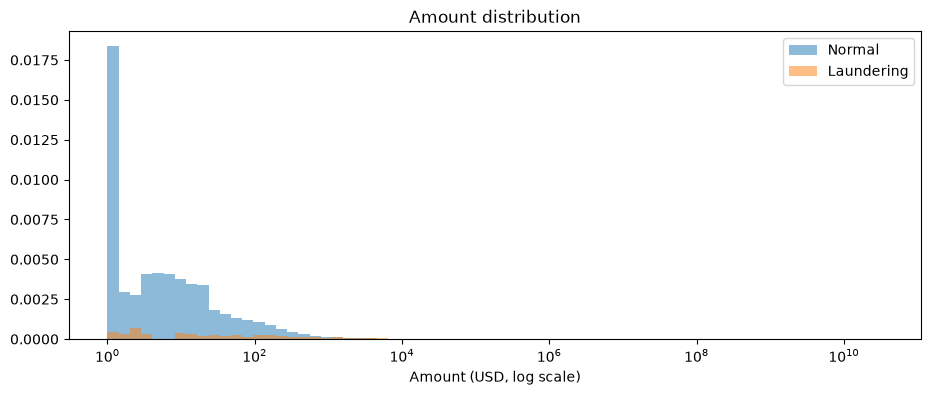

,count,mean,std,min,25%,50%,75%,99%,max
is_laundering,,,,,,,,,
0,"5,073,168.0000","346,030.8567","23,233,414.7798",0.0001,158.0000,891.0500,"5,273.8331","3,099,715.3200","26,558,613,301.7214"
1,"5,177.0000","5,169,483.6401","231,331,481.7001",0.3867,"2,160.5600","5,878.8063","13,758.5029","15,793,198.1262","16,297,043,812.7494"


In [61]:
x_all = df["amt_usd"].clip(lower=1)
bins = np.logspace(0, np.log10(x_all.max()) + 0.1, 70)
fig, ax = plt.subplots(figsize=(11, 4))
for label, name in [(0, "Normal"), (1, "Laundering")]:
    ax.hist(df.loc[df.is_laundering == label, "amt_usd"].clip(lower=1), bins=bins, density=True, alpha=0.5, label=name)
ax.set_xscale("log"); ax.set_xlabel("Amount (USD, log scale)"); ax.set_title("Amount distribution"); ax.legend()
plt.show()
display(df.groupby("is_laundering")["amt_usd"].describe(percentiles=[.25, .5, .75, .99]))

**Hallazgos**

- Los montos abarcan ~14 órdenes de magnitud (de 0.0001 a 2.6×10¹⁰ USD).
- Los montos de lavado suelen ser mayores (mediana ≈ 5,879 USD vs 891 USD en transacciones normales), pero las se traslapan mucho, así que el monto solo no separa las clases.

**Decisiones**

Usamos `log(1 + monto)` para que los valores extremos no dominen, más el monto **relativo al monto típico del propio emisor** en la secuencia ("inusualmente grande para esta persona").

## 4. Tiempo

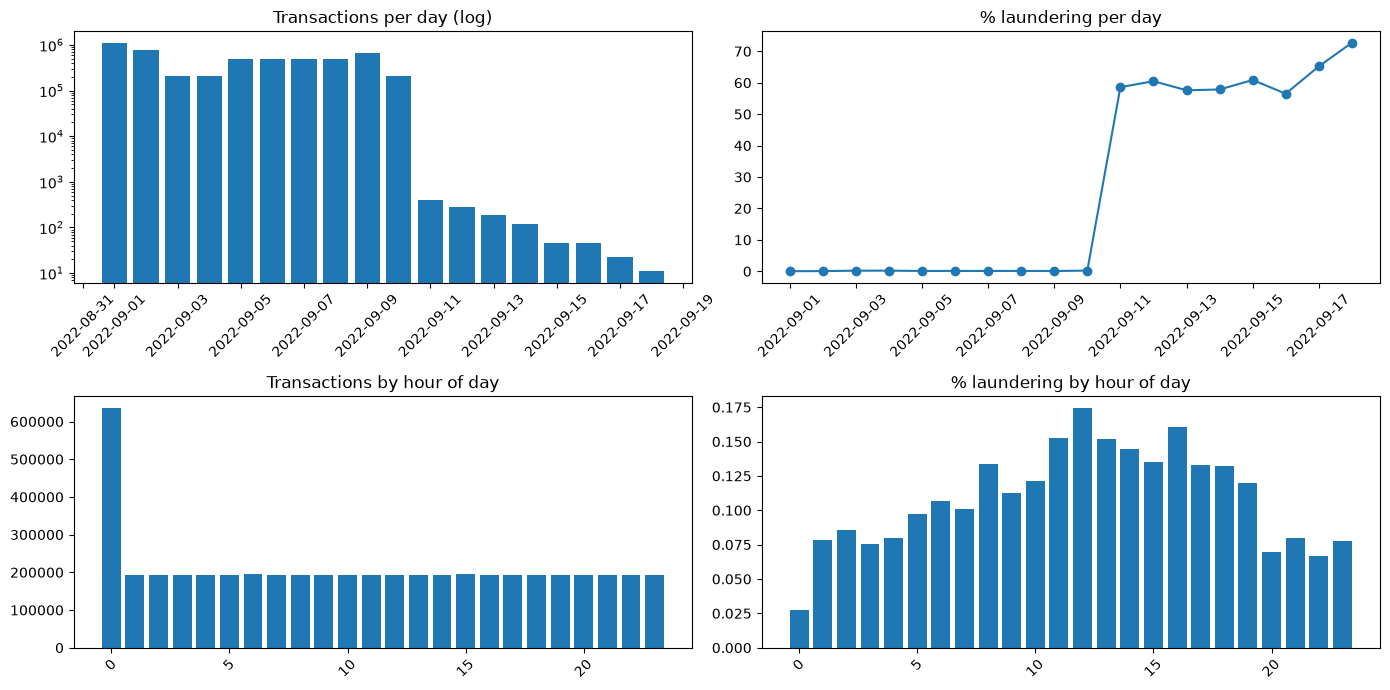

,size,mean
ts,,
2022-09-01,1114921,0.0003
2022-09-02,754449,0.0005
2022-09-03,207382,0.0019
2022-09-04,207430,0.0020
2022-09-05,482650,0.0010
2022-09-06,482089,0.0011
2022-09-07,482751,0.0010
2022-09-08,482773,0.0011
2022-09-09,654467,0.0008


In [62]:
daily = df.set_index("ts").resample("D")["is_laundering"].agg(["size", "mean"])
hourly = df.groupby(df.ts.dt.hour)["is_laundering"].agg(["size", "mean"])
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
ax[0, 0].bar(daily.index, daily["size"]); ax[0, 0].set_yscale("log"); ax[0, 0].set_title("Transactions per day (log)")
ax[0, 1].plot(daily.index, daily["mean"] * 100, marker="o"); ax[0, 1].set_title("% laundering per day")
ax[1, 0].bar(hourly.index, hourly["size"]); ax[1, 0].set_title("Transactions by hour of day")
ax[1, 1].bar(hourly.index, hourly["mean"] * 100); ax[1, 1].set_title("% laundering by hour of day")
for a in ax.flat:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
display(daily)

**Qué encontramos**

- La actividad normal se detiene después del 2022-09-10. Del 09-11 al 09-18 solo hay ~1,100 transacciones, y ~60% son lavado. El simulador sigue corriendo intentos de lavado que ya estaban en curso
  después de que el resto de la economía se detiene.
- El día 1 tiene ~1.1M transacciones y algunos días ~200k: es scheduling del simulador, no comportamiento real.
- La hora 0 tiene ~630k transacciones vs ~190k en cualquier otra hora, y la tasa de lavado más baja.

Dos chequeos de seguimiento. Xuánto lavado vive solo en la cola, y qué es el pico de medianoche.

In [63]:
TAIL_START = "2022-09-11"
tail = df["ts"] >= pd.Timestamp(TAIL_START)
laund = df["is_laundering"] == 1
pre_senders = set(df.loc[~tail & laund, "sender"].unique())
tail_senders = set(df.loc[tail & laund, "sender"].unique())
print(f"Tail transactions: {int(tail.sum()):,} ({df.loc[tail, 'is_laundering'].mean():.1%} laundering)")
print(f"Laundering tx in tail: {int((tail & laund).sum()):,} of {int(laund.sum()):,} "
      f"({(tail & laund).sum() / laund.sum():.1%})")
print(f"Positive senders whose laundering happens ONLY in the tail: {len(tail_senders - pre_senders):,} "
      f"of {len(pre_senders | tail_senders):,}")

hour = df["ts"].dt.hour
at_midnight = (hour == 0) & (df["ts"].dt.minute == 0)
print(f"\nHour-0 transactions: {int((hour == 0).sum()):,}, of which exactly 00:00: {at_midnight[hour == 0].mean():.1%}")
print(f"Laundering rate at 00:00: {df.loc[at_midnight, 'is_laundering'].mean():.4%} | "
      f"rest of the day: {df.loc[~at_midnight, 'is_laundering'].mean():.4%}")
display(pd.DataFrame({"share at 00:00": df.loc[at_midnight, "pay_format"].value_counts(normalize=True),
                      "share overall": df["pay_format"].value_counts(normalize=True)}))
del tail, laund, hour, at_midnight

Tail transactions: 1,108 (59.1% laundering)
Laundering tx in tail: 655 of 5,177 (12.7%)
Positive senders whose laundering happens ONLY in the tail: 340 of 3,376

Hour-0 transactions: 634,726, of which exactly 00:00: 2.8%
Laundering rate at 00:00: 0.0166% | rest of the day: 0.1022%


,share at 00:00,share overall
pay_format,,
ACH,0.0507,0.1183
Bitcoin,0.0296,0.0288
Cash,0.0329,0.0967
Cheque,0.1193,0.3671
Credit Card,0.3238,0.2606
Reinvestment,0.4282,0.0947
Wire,0.0156,0.0338


**Hallazgos**

- La cola tiene 1,108 transacciones, 59% lavado: **655 transacciones de lavado (12.7% del total)**.
- **340 de los 3,376 emisores positivos (10%) lavan solo en la cola.** Si se descartara la cola, se perderían.
- **El pico de medianoche no es un batch de medianoche.** La hora 0 tiene 634,726 transacciones, pero solo 2.8%
  están marcadas exactamente 00:00; el resto se reparte en la hora. Las pocas transacciones de las 00:00 son 43%
  Reinvestment (9% en general) y tienen tasa de lavado de 0.017% vs 0.10% el resto del día.
- Los volúmenes diarios saltan entre niveles fijos (1.1M, 750k, 480k, 207k) y la tasa de lavado por hora sigue la
  misma forma. La hora del día en este dataset refleja cómo programa actividad el simulador.

**Decisiones**

**Mantenemos la cola, pero nunca le damos tiempo absoluto al modelo.** Sin fechas, índices de día ni "días desde
el inicio", solo el gap desde la transacción previa del emisor. El split se estratifica por presencia en la
cola, y después de modelar revisamos si los positivos de la cola se detectan sospechosamente más que el resto.

**Descartamos hora del día por completo, incluyendo la bandera de medianoche.** Una versión anterior tenía un
flag `is_midnight` y features de hora del día. El chequeo de arriba muestra que la bandera describía casi nada
(2.8% de la hora 0) y que el patrón horario es un artefacto del simulador.

## 5. Formatos de pago

In [64]:
fmt_tbl = (df.groupby("pay_format", observed=True)
             .agg(transactions=("tx_id", "size"), laundering=("is_laundering", "sum"), self_share=("is_self", "mean")))
fmt_tbl["laundering rate"] = fmt_tbl["laundering"] / fmt_tbl["transactions"]
fmt_tbl["share of all laundering"] = fmt_tbl["laundering"] / fmt_tbl["laundering"].sum()
display(fmt_tbl.sort_values("laundering", ascending=False))

,transactions,laundering,self_share,laundering rate,share of all laundering
pay_format,,,,,
ACH,600797,4483,0.1188,0.0075,0.8659
Cheque,1864331,324,0.0033,0.0002,0.0626
Credit Card,1323324,206,0.0032,0.0002,0.0398
Cash,490891,108,0.0030,0.0002,0.0209
Bitcoin,146091,56,0.1801,0.0004,0.0108
Reinvestment,481056,0,1.0000,0.0000,0.0000
Wire,171855,0,0.0046,0.0000,0.0000


**Hallazgos**

- **ACH concentra 4,483 de las 5,177 transacciones de lavado (87%)**, una tasa de 0.75% vs ≤0.04% en el resto.
- **Wire (172k tx) y Reinvestment (481k tx) tienen cero lavado.** Reinvestment es casi todo auto-transferencias.

**Decisiones**

**Mantenemos ambos formatos en los datos**: forman parte del comportamiento real de cada emisor, y quitarlos
distorsionaría gaps y frecuencias. El modelo aprenderá que estos formatos se ven normales; eso es cierto aquí
pero puede no generalizar, y va en las limitaciones.

**Subsampleamos, solo en entrenamiento, emisores cuyas secuencias son puro Wire/Reinvestment.** Son negativos
garantizados y en su mayoría le enseñan al modelo una regla fácil. Validación y test conservan a todos los
emisores para que las métricas reflejen la distribución real.

In [65]:
WR_FORMATS = ["Wire", "Reinvestment"]
WR_ONLY_KEEP_FRAC = 0.20      # fraction of Wire/Reinvestment-only senders kept in the TRAINING split

## 6. Tipologías de lavado

In [66]:
# --- 2.3 Typologies from HI-Small_Patterns.txt (analysis only, never a model feature)
begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z\- ]+?)\s*(?::|$)")
rows, attempt_id, ptype = [], -1, None
with open(PATTERNS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("BEGIN"):
            attempt_id += 1
            m = begin_re.match(line)
            ptype = m.group(1).strip().upper() if m else "UNKNOWN"
        elif line.startswith("END"):
            ptype = None
        elif ptype is not None:
            parts = line.split(",")
            if len(parts) == len(COLS):
                rows.append([attempt_id, ptype] + parts)

pat = pd.DataFrame(rows, columns=["attempt_id", "pattern"] + COLS)
pat["ts"] = pd.to_datetime(pat["ts"], format="%Y/%m/%d %H:%M")
pat["from_bank"] = pat["from_bank"].astype("int64")
pat["to_bank"] = pat["to_bank"].astype("int64")
pat["amt_paid"] = pat["amt_paid"].astype("float64").round(2)

KEYS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_paid"]
right = df.loc[df.is_laundering == 1, KEYS + ["tx_id"]].copy()
right["amt_paid"] = right["amt_paid"].round(2)
for t in (pat, right):
    t["from_acct"] = t["from_acct"].astype(str)
    t["to_acct"] = t["to_acct"].astype(str)
matched = pat.merge(right.drop_duplicates(KEYS), on=KEYS, how="left").dropna(subset=["tx_id"])
tx_pattern = matched.drop_duplicates("tx_id").set_index("tx_id")
df["pattern"] = df["tx_id"].map(tx_pattern["pattern"])
df["attempt_id"] = df["tx_id"].map(tx_pattern["attempt_id"])
print(f"Pattern tx parsed: {len(pat):,} | laundering tx with typology: "
      f"{df.loc[df.is_laundering == 1, 'pattern'].notna().mean():.1%}")

# drop raw string columns we no longer need (memory)
df = df.drop(columns=["from_acct", "to_acct", "amt_received", "recv_currency"])
del pat, right, matched, tx_pattern, rows
gc.collect()
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB {elapsed()}")

Pattern tx parsed: 3,209 | laundering tx with typology: 62.0%
Memory: 0.44 GB [98.2 min]


In [67]:
display(df.loc[df.is_laundering == 1, "pattern"].fillna("(no typology)").value_counts().to_frame("laundering tx"))

,laundering tx
pattern,
(no typology),1968
GATHER-SCATTER,716
SCATTER-GATHER,626
STACK,466
FAN-OUT,342
FAN-IN,318
CYCLE,287
BIPARTITE,263
RANDOM,191


**Hallazgos**

- 8 tipologías (fan-out, fan-in, cycle, bipartite, stack, scatter-gather, gather-scatter, random), 40–54 intentos
  cada una; 100% de las transacciones del archivo de patrones calzan con el archivo principal.
- Solo **62% de las transacciones de lavado pertenecen a una tipología listada**; el resto es lavado sin patrón
  nombrado.
- Varias tipologías son patrones de grafo (ej. fan-in = muchos emisores → un receptor). Vistas desde la secuencia
  de un solo emisor, algunas se ven como una transacción ordinaria más.

**Decisiones**

Las tipologías **nunca se usan como features** (son etiquetas disfrazadas). Se usan después de modelar, para ver
qué patrones detecta cada stage y para conectar la atención con comportamientos de lavado conocidos en el
análisis de interpretabilidad. Que la vista por emisor no vea patrones del lado del receptor queda como
limitación explícita.

## 7. Historias de emisores y largo mínimo

Senders: 496,999 | positive senders (ever laundered): 3,376 (0.679%)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,99.9%,max
transactions per sender,"496,999.0000",10.2180,290.2829,1.0000,1.0000,2.0000,5.0000,29.0000,46.0000,92.0000,159.0000,"168,672.0000"


,min length,% senders dropped,% transactions dropped,positive senders dropped,% positive senders dropped
0,1,0.0000,0.0000,0,0.0000
1,2,30.7353,3.0079,122,3.6137
2,3,62.5768,9.2404,618,18.3057
3,4,71.3669,11.8212,1291,38.2405
4,5,74.0887,12.8866,1750,51.8365
5,10,77.8655,15.2840,2191,64.8993
6,20,84.5406,24.4372,2489,73.7263


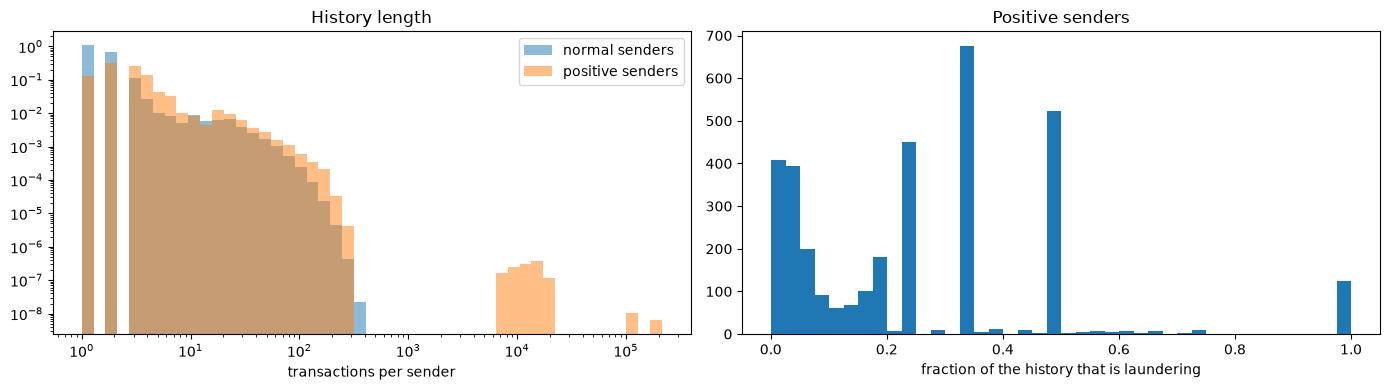

In [68]:
# order every sender's history chronologically; everything from here on relies on this order
df = df.sort_values(["sender", "ts", "tx_id"], kind="stable").reset_index(drop=True)
g = df.groupby("sender", sort=False)
sender_ntx = g["tx_id"].size()
sender_ever = g["is_laundering"].max()
counts = sender_ntx.to_numpy()
offsets = np.concatenate([[0], np.cumsum(counts)[:-1]])      # first row of each sender in df
assert (np.diff(df["sender"].to_numpy()) >= 0).all()

print(f"Senders: {len(counts):,} | positive senders (ever laundered): {int(sender_ever.sum()):,} "
      f"({sender_ever.mean():.3%})")
display(sender_ntx.describe(percentiles=[.25, .5, .75, .9, .95, .99, .999]).to_frame("transactions per sender").T)

rows = []
for k in [1, 2, 3, 4, 5, 10, 20]:
    short = counts < k
    rows.append({"min length": k, "% senders dropped": short.mean() * 100,
                 "% transactions dropped": counts[short].sum() / counts.sum() * 100,
                 "positive senders dropped": int(sender_ever.to_numpy()[short].sum()),
                 "% positive senders dropped": sender_ever.to_numpy()[short].sum() / sender_ever.sum() * 100})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bins = np.logspace(0, np.log10(counts.max()) + 0.1, 50)
ax[0].hist(counts[sender_ever.to_numpy() == 0], bins=bins, density=True, alpha=0.5, label="normal senders")
ax[0].hist(counts[sender_ever.to_numpy() == 1], bins=bins, density=True, alpha=0.5, label="positive senders")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_xlabel("transactions per sender"); ax[0].set_title("History length")
pos = sender_ever.to_numpy() == 1
ax[1].hist(g["is_laundering"].mean().to_numpy()[pos], bins=40)
ax[1].set_xlabel("fraction of the history that is laundering"); ax[1].set_title("Positive senders")
plt.tight_layout(); plt.show()

**Qué encontramos**

- 496,999 emisores; 3,376 lavan alguna vez (0.68%, ~1 de cada 147).
- **La mayoría de los emisores son muy cortos**: mediana 2 transacciones, percentil 75 en 5. Una cola larga llega
  hasta una cuenta con 168,672 transacciones.
- **Los emisores positivos son especialmente cortos.** Largo mínimo 3 descarta 618 emisores positivos (18%);
  largo mínimo 2 descarta solo 122 (3.6%) mientras quita el 31% de emisores con una sola transacción.
- En nuestra primera versión (mínimo 3) quedaban 185,993 emisores y 2,758 positivos.

**Qué hacemos al respecto**

**Largo mínimo 2.** Una sola transacción no tiene secuencia, no se
puede modelar como comportamiento en el tiempo. Desde dos transacciones ya hay al menos una relación entre
eventos. Bajar de 3 a 2 recupera ~500 emisores positivos (+18%), que importa mucho cuando los positivos son tan
escasos. Los emisores de una sola transacción quedan fuera del alcance de un modelo de secuencias y necesitarían
un modelo por transacción (limitación).

In [69]:
MIN_LEN = 2

## 8. Largo de ventana, stride y tope

Las secuencias son ventanas de largo fijo sobre la historia de cada emisor:

- Emisores con a lo más `L` transacciones dan **una** ventana (toda su historia).
- Emisores más largos dan ventanas solapadas: la primera termina en la transacción más reciente, cada siguiente
  empieza `stride` transacciones antes, y la última empieza en la primera transacción. Se guardan a lo más `cap`
  ventanas (las más recientes). Ejemplo con `L=32`, `stride=16`, 60 transacciones: ventanas de tx 29–60, 13–44,
  1–32.
- Cada ventana se etiqueta positiva si contiene una transacción de lavado.

En nuestra primera versión (`L=64`, `stride=32`, `cap=8`, largo mínimo 3) las ventanas solapadas casi no
importaban: agregaron 19k ventanas (205,280 vs 185,993 emisores) y recuperaron solo 30 emisores positivos, porque
solo ~2.6% de emisores tiene más de 64 transacciones. La tabla de abajo compara configuraciones antes de elegir.

In [70]:
def plan_windows(n_tx, L, stride, cap):
    """Window layout for senders with n_tx transactions.
    Returns per window: owner (index into n_tx), rank (0 = most recent), start index, length."""
    n_tx = np.asarray(n_tx, dtype=np.int64)
    over = np.maximum(n_tx - L, 0)                          # transactions beyond a single window
    k_full = over // stride + 1                             # windows anchored at the most recent tx
    extra = (over % stride != 0).astype(np.int64)           # plus one window starting at tx 0
    n_win = np.minimum(k_full + extra, cap)
    owner = np.repeat(np.arange(len(n_tx)), n_win)
    rank = np.arange(n_win.sum()) - np.repeat(np.cumsum(n_win) - n_win, n_win)
    start = np.where(rank < k_full[owner], over[owner] - rank * stride, 0)
    length = np.minimum(n_tx[owner], L)
    return owner, rank, start, length

# helpers computed once: laundering prefix sums and the last laundering position of each sender
laund_arr = df["is_laundering"].to_numpy().astype(np.int64)
laund_prefix = np.concatenate([[0], np.cumsum(laund_arr)])
pos_in_sender = np.arange(len(df)) - np.repeat(offsets, counts)
last_laund = np.full(len(counts), -1, dtype=np.int64)
lm = laund_arr == 1
np.maximum.at(last_laund, np.repeat(np.arange(len(counts)), counts)[lm], pos_in_sender[lm])
N_POS_TOTAL = int((last_laund >= 0).sum())

def describe_config(min_len, L, stride, cap, n_features=9):
    elig = np.flatnonzero(counts >= min_len)
    owner, rank, start, length = plan_windows(counts[elig], L, stride, cap)
    first_row = offsets[elig][owner] + start
    pos_windows = (laund_prefix[first_row + length] - laund_prefix[first_row]) > 0
    n_win = np.bincount(owner, minlength=len(elig))
    oldest_start = start[np.cumsum(n_win) - 1]               # windows overlap, so coverage = [oldest_start, end)
    covered = last_laund[elig] >= oldest_start
    return {"min len": min_len, "L": L, "stride": stride, "cap": cap,
            "senders": len(elig), "windows": len(owner),
            "positive senders": int(covered.sum()),
            "% of all positive senders": covered.sum() / N_POS_TOTAL * 100,
            "positive windows": int(pos_windows.sum()),
            "positive window rate %": pos_windows.mean() * 100,
            "senders with >1 window": int((n_win > 1).sum()), "senders at cap": int((n_win == cap).sum()),
            "tx rows (with overlap)": int(length.sum()),
            "X_num GB": len(owner) * L * n_features * 4 / 1e9,
            "compute (windows×L, M)": len(owner) * L / 1e6}

grid = [(3, 64, 32, 8)]                                       # first version, for reference
grid += [(m, L, L // 2, 8) for m in (1, 2, 3) for L in (32, 48, 64) if (m, L) != (3, 64)]
grid += [(2, 32, 16, 12), (2, 32, 8, 8)]
config_tbl = pd.DataFrame([describe_config(*c) for c in grid])
pd.set_option("display.max_columns", 30)
display(config_tbl)
print(elapsed())

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,3,64,32,8,185993,205280,2747,81.3685,2909,1.4171,12847,27,5017478,0.4730,13.1379
1,1,32,16,8,496999,590607,3364,99.6445,3771,0.6385,41927,1448,6446170,0.6804,18.8994
2,1,48,24,8,496999,537489,3365,99.6742,3598,0.6694,23291,156,5910620,0.9288,25.7995
3,1,64,32,8,496999,516286,3365,99.6742,3527,0.6831,12847,27,5486736,1.1895,33.0423
4,2,32,16,8,344245,437853,3242,96.0308,3649,0.8334,41927,1448,6293416,0.5044,14.0113
5,2,48,24,8,344245,384735,3243,96.0604,3476,0.9035,23291,156,5757866,0.6648,18.4673
6,2,64,32,8,344245,363532,3243,96.0604,3405,0.9366,12847,27,5333982,0.8376,23.2660
7,3,32,16,8,185993,279601,2746,81.3389,3153,1.1277,41927,1448,5976912,0.3221,8.9472
8,3,48,24,8,185993,226483,2747,81.3685,2980,1.3158,23291,156,5441362,0.3914,10.8712
9,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


[98.2 min]


**Hallazgos**

- **El largo mínimo importa mucho más que el tamaño de ventana.** Con mínimo 3, toda configuración conserva
  ~2,747 emisores positivos (81%). Con mínimo 2 son ~3,243 (96%). Mínimo 1 solo suma ~120 positivos más, al costo
  de ~150k ventanas de una sola transacción y la tasa positiva más baja (0.64%).
- **Con mínimo 2, el tamaño de ventana casi no cambia los positivos (3,242–3,243) pero sí cambia el costo.**
  L=32 da 437,853 ventanas usando 0.62 GB y 14.0M de cómputo; L=48 da 384,735 ventanas (0.81 GB, 18.5M); L=64 da
  363,532 ventanas (1.02 GB, 23.3M). Ventanas más cortas significan más ejemplos por menos cómputo.
- Con L=32, 41,927 emisores tienen más de una ventana, contra 12,847 con L=64: las ventanas solapadas sí hacen
  algo ahora.
- Un tope de 8 deja 1,448 emisores en el tope. Un tope de 12 lo baja a 156 por solo 1,737 ventanas extra (+0.4%)
  y conserva un emisor positivo más.
- Un stride de 8 agrega ~50k ventanas, pone a 7,360 emisores en el tope y termina con menos positivos (3,232).
- Comparado con nuestra primera versión (fila 0), la configuración nueva conserva 496 emisores positivos más
  (2,747 → 3,243) y tiene 2.1× las ventanas por casi el mismo cómputo (14.1M vs 13.1M).

**Decisiones**

Usamos **largo mínimo 2, ventanas de 32 transacciones, stride 16 y a lo más 12 ventanas por emisor** (fila 9).

32 transacciones siguen cubriendo toda la historia de la mayoría de emisores y alcanzan para los intentos de
lavado del archivo de tipologías (5 a 14 transacciones cada uno). Ventanas con medio solape significan que un
patrón cortado por un borde de ventana aparece completo en la siguiente; un stride menor solo repite las mismas
transacciones más veces. El tope de 12 significa que una cuenta muy activa aporta a lo más 12 ventanas (sus
últimas 208 transacciones), así que no puede dominar el entrenamiento, aunque casi nadie llega realmente al tope.

In [71]:
MAX_LEN = 32
STRIDE = 16
MAX_WINDOWS_PER_SENDER = 12
display(pd.DataFrame([describe_config(MIN_LEN, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)]))

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


## 9. Features de transacción

Cada transacción de una ventana se describe con los features de abajo. Todo es intrínseco a la transacción o
**relativo a la propia historia del emisor**

| Feature | Significado | Motivado por |
|---|---|---|
| `log_amt` | log(1 + monto en USD) | Parte 3: los montos abarcan 14 órdenes de magnitud |
| `amt_rel` | log del monto menos la mediana log de la ventana | Parte 3: "inusual para este emisor" |
| `log_gap` | log(1 + minutos desde la transacción previa del emisor) | Parte 4: solo tiempo relativo; ráfagas |
| `is_first` | primera transacción vista del emisor | no hay transacción previa para el gap |
| `is_self` | emisor == receptor | Parte 2 / 5: reinvestment |
| `same_bank` | mismo banco en ambos lados | movimiento entre bancos |
| `is_cross_currency` | se paga y recibe en monedas distintas | Parte 3 |
| `is_new_receiver` | primera vez que este emisor paga a este receptor | destinos que cambian abruptamente |
| `log_recv_senders` | log(1 + emisores distintos que le han pagado a este receptor **hasta ahora**) | Parte 6: fan-in / gather |
| `pay_format` | formato de pago (embedding aprendido) | Parte 5: concentración en ACH |
| `pay_currency` | moneda de pago (embedding aprendido) | Parte 3 |

**Por qué `log_recv_senders`.** Una secuencia por emisor no puede ver patrones de red: en un fan-in, cada emisor
hace un pago que se ve ordinario, y solo el receptor junta de muchas cuentas (nuestro primer Stage A detectó 6%
de los emisores de fan-in). Este feature le da a cada pago algo de contexto sobre a dónde va el dinero. Se
calcula **punto-en-el-tiempo** (solo transacciones hasta ese momento) y no usa etiquetas, así que no mira al
futuro ni filtra la respuesta. Igual se calcula sobre todas las cuentas del dataset, cosa que un banco real solo
podría hacer para los receptores que puede observar (limitación).

Sin hora del día ni bandera de medianoche (Parte 4). Los features numéricos se estandarizan en la Parte 11 con
estadísticas de entrenamiento solamente.

In [72]:
assert (np.diff(df["sender"].to_numpy()) >= 0).all(), "df must still be sorted by sender, time"
g = df.groupby("sender", sort=False)

gap_min = (df["ts"] - g["ts"].shift(1)).dt.total_seconds() / 60.0
df["is_first"] = gap_min.isna().astype(np.float32)
df["log_gap"] = np.log1p(gap_min.fillna(0).clip(lower=0)).astype(np.float32)
df["log_amt"] = np.log1p(df["amt_usd"].clip(lower=0)).astype(np.float32)

df["is_new_receiver"] = (~df.duplicated(["sender", "receiver"])).astype(np.float32)

# distinct senders that have paid each receiver up to (and including) this transaction, in time order
order = np.lexsort((df["tx_id"].to_numpy(), df["receiver"].to_numpy()))
r_sorted, s_sorted = df["receiver"].to_numpy()[order], df["sender"].to_numpy()[order]
new_pair = ~pd.DataFrame({"r": r_sorted, "s": s_sorted}).duplicated().to_numpy()
cum_senders = pd.Series(new_pair.astype(np.int64)).groupby(r_sorted).cumsum().to_numpy()
recv_senders = np.empty(len(df), dtype=np.int64)
recv_senders[order] = cum_senders
df["log_recv_senders"] = np.log1p(recv_senders).astype(np.float32)
del order, r_sorted, s_sorted, new_pair, cum_senders, recv_senders

FMT_NAMES = list(df["pay_format"].cat.categories.astype(str))
CUR_NAMES = list(df["pay_currency"].cat.categories.astype(str))
df["fmt_code"] = (df["pay_format"].cat.codes + 1).astype(np.int16)      # 0 is reserved for padding
df["cur_code"] = (df["pay_currency"].cat.codes + 1).astype(np.int16)

# analysis-only flags, never fed to the model
df["is_tail"] = (df["ts"] >= pd.Timestamp(TAIL_START)).astype(np.int8)
df["is_wr"] = df["pay_format"].astype(str).isin(WR_FORMATS).to_numpy().astype(np.int8)

NUM_FEATURES = ["log_amt", "amt_rel", "log_gap", "is_first", "is_self", "same_bank", "is_cross_currency",
                "is_new_receiver", "log_recv_senders"]
CONT_FEATURES = ["log_amt", "amt_rel", "log_gap", "log_recv_senders"]
del gap_min, g
print(f"Formats: {FMT_NAMES} | currencies: {len(CUR_NAMES)} {elapsed()}")

Formats: ['ACH', 'Bitcoin', 'Cash', 'Cheque', 'Credit Card', 'Reinvestment', 'Wire'] | currencies: 15 [98.2 min]


Un chequeo rápido de que el feature de receptor sí trae información, sobre todo para fan-in:

In [73]:
chk = df.assign(recv_senders=np.expm1(df["log_recv_senders"]),
                group=np.where(df["is_laundering"] == 1, df["pattern"].fillna("laundering, no typology"), "normal"))
display(chk.groupby("group")["recv_senders"].describe(percentiles=[.5, .9])[["count", "50%", "90%", "mean"]]
          .sort_values("50%", ascending=False))
del chk

,count,50%,90%,mean
group,,,,
FAN-IN,318.0000,8.0000,15.0000,8.7075
GATHER-SCATTER,716.0000,5.0000,12.0000,5.9944
RANDOM,191.0000,4.0000,5.0000,3.5340
BIPARTITE,263.0000,4.0000,5.0000,3.4753
SCATTER-GATHER,626.0000,4.0000,12.0000,5.9105
CYCLE,287.0000,3.0000,5.4000,3.6098
FAN-OUT,342.0000,3.0000,5.0000,3.5760
STACK,466.0000,3.0000,5.0000,3.3519
"laundering, no typology","1,968.0000",3.0000,7.0000,4.3120


## 10. Construcción de secuencias

In [74]:
# --- windows for the chosen configuration
elig = counts >= MIN_LEN
e_ids, e_cnt, e_off = sender_ntx.index.to_numpy()[elig], counts[elig], offsets[elig]
win_owner, win_rank, win_start, win_len = plan_windows(e_cnt, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)

N = len(win_start)
rep = np.repeat(np.arange(N), win_len)
pos = np.arange(win_len.sum()) - np.repeat(np.cumsum(win_len) - win_len, win_len)
rows = e_off[win_owner][rep] + win_start[rep] + pos

W_COLS = ["sender", "receiver", "tx_id", "ts", "amt_usd", "pay_format", "pay_currency", "fmt_code", "cur_code",
          "is_laundering", "pattern", "attempt_id", "is_tail", "is_wr"] + [f for f in NUM_FEATURES if f != "amt_rel"]
w = df[W_COLS].take(rows).reset_index(drop=True)
w["seq"] = rep.astype(np.int32)
w["pos"] = pos.astype(np.int16)
w["amt_rel"] = (w["log_amt"] - w.groupby("seq")["log_amt"].transform("median")).astype(np.float32)

# --- one row per window
seqs = w.groupby("seq").agg(
    sender=("sender", "first"), length=("pos", "size"), label=("is_laundering", "max"),
    n_laund=("is_laundering", "sum"), has_tail=("is_tail", "max"), only_wr=("is_wr", "min"),
    first_ts=("ts", "min"), last_ts=("ts", "max"))
assert (seqs.index.to_numpy() == np.arange(N)).all()
seqs["win_rank"] = win_rank
seqs["win_start"] = win_start
seqs["n_tx_total"] = e_cnt[win_owner]
seqs["ever_label"] = seqs["sender"].map(sender_ever).astype(np.int8)
seqs["sender_name"] = ACCOUNT_NAMES[seqs["sender"].to_numpy()]
seqs["pattern"] = (w.dropna(subset=["pattern"]).groupby("seq")["pattern"]
                     .agg(lambda s: s.value_counts().index[0])).reindex(seqs.index)

# --- one row per sender
senders = seqs.groupby("sender").agg(n_windows=("label", "size"), label=("label", "max"),
                                     has_tail=("has_tail", "max"), only_wr=("only_wr", "min"),
                                     n_tx_total=("n_tx_total", "first"), sender_name=("sender_name", "first"))
senders["ever_label"] = senders.index.map(sender_ever).astype(np.int8)
senders["pattern"] = (w.dropna(subset=["pattern"]).groupby("sender")["pattern"]
                        .agg(lambda s: s.value_counts().index[0])).reindex(senders.index)

print(f"Senders: {len(senders):,} | windows: {N:,} | positive senders: {int(senders.label.sum()):,} | "
      f"positive windows: {int(seqs.label.sum()):,}")
print(f"Positive senders lost to the window cap: {int(((senders.ever_label == 1) & (senders.label == 0)).sum()):,} "
      f"| transaction rows: {len(w):,} {elapsed()}")

Senders: 344,245 | windows: 439,590 | positive senders: 3,243 | positive windows: 3,657
Positive senders lost to the window cap: 11 | transaction rows: 6,349,000 [98.3 min]


In [75]:
# dense padded arrays: (N windows, MAX_LEN positions, F features), left-aligned, oldest first
L, F_NUM = MAX_LEN, len(NUM_FEATURES)
r, c = w["seq"].to_numpy(), w["pos"].to_numpy()

X_num = np.zeros((N, L, F_NUM), dtype=np.float32)
X_num[r, c] = w[NUM_FEATURES].to_numpy(np.float32)
X_fmt = np.zeros((N, L), dtype=np.int16); X_fmt[r, c] = w["fmt_code"].to_numpy()
X_cur = np.zeros((N, L), dtype=np.int16); X_cur[r, c] = w["cur_code"].to_numpy()
MASK = np.zeros((N, L), dtype=bool); MASK[r, c] = True
Y_TX = np.zeros((N, L), dtype=np.int8); Y_TX[r, c] = w["is_laundering"].to_numpy()   # analysis only
TX_ID = np.full((N, L), -1, dtype=np.int64); TX_ID[r, c] = w["tx_id"].to_numpy()
y_seq = seqs["label"].to_numpy().astype(np.int8)

print(f"X_num {X_num.shape}, {X_num.nbytes / 1e9:.2f} GB {elapsed()}")

X_num (439590, 32, 9), 0.51 GB [98.3 min]


## 11. Sets de train, validación y test

Dividimos por **emisor**, no por ventana. Las ventanas solapadas de un mismo emisor comparten transacciones, así que
si una fuera a train y otra a test, el modelo ya habría visto parte del test. Cada ventana hereda el split de su
emisor.

El split es 70/15/15, estratificado por si el emisor tiene una ventana positiva y si toca la cola, para que cada
set tenga la misma proporción de positivos y de casos de cola.

Dos pasos más usan solo el set de entrenamiento. Se subsamplean los emisores puro Wire/Reinvestment (Parte 5), y
los features continuos se estandarizan con la media y desviación de entrenamiento, para que nada de validación o
test se filtre a los inputs.

In [76]:
SPLIT_FRACS = (0.70, 0.15, 0.15)

def stratified_split(strata, fracs, seed):
    rng = np.random.default_rng(seed)
    out = np.empty(len(strata), dtype=np.int8)
    for s in np.unique(strata):
        idx = np.flatnonzero(strata == s)
        rng.shuffle(idx)
        n_tr = int(round(fracs[0] * len(idx)))
        n_va = int(round(fracs[1] * len(idx)))
        out[idx[:n_tr]], out[idx[n_tr:n_tr + n_va]], out[idx[n_tr + n_va:]] = 0, 1, 2
    return out

# split SENDERS, then every window inherits its sender's split
strata = senders["label"].to_numpy() * 2 + senders["has_tail"].to_numpy()
senders["split"] = np.array(["train", "val", "test"])[stratified_split(strata, SPLIT_FRACS, SEED)]

rng = np.random.default_rng(SEED + 1)
drop_wr = ((senders["split"] == "train") & (senders["only_wr"] == 1)
           & (rng.random(len(senders)) >= WR_ONLY_KEEP_FRAC))
assert senders.loc[drop_wr, "ever_label"].sum() == 0, "a dropped WR-only sender was positive"
senders["train_keep"] = (senders["split"] == "train") & ~drop_wr
print(f"Wire/Reinvestment-only senders in train: {int(((senders.split == 'train') & (senders.only_wr == 1)).sum()):,} "
      f"-> dropped {int(drop_wr.sum()):,}")

seqs["split"] = seqs["sender"].map(senders["split"])
seqs["train_keep"] = seqs["sender"].map(senders["train_keep"]).astype(bool)

# standardize continuous features with training statistics (valid positions only)
train_idx = np.flatnonzero(seqs["train_keep"].to_numpy())
NORM = {}
for f in CONT_FEATURES:
    j = NUM_FEATURES.index(f)
    vals = X_num[train_idx, :, j][MASK[train_idx]]
    mu, sd = float(vals.mean()), float(vals.std() + 1e-6)
    NORM[f] = {"mean": mu, "std": sd}
    X_num[:, :, j] = np.where(MASK, (X_num[:, :, j] - mu) / sd, 0.0)
display(pd.DataFrame(NORM).T)
print(elapsed())

Wire/Reinvestment-only senders in train: 40,413 -> dropped 32,371


,mean,std
log_amt,6.9571,2.7944
amt_rel,0.0485,2.2810
log_gap,3.7030,2.5359
log_recv_senders,1.3379,0.3346


[98.3 min]


Estos son los sets que se usan de aquí en adelante. Stage A solo ve emisores de entrenamiento que nunca
lavaron; Stage B y el baseline desde cero entrenan con todos los emisores de entrenamiento (los que quedan);
validación es para early stopping y umbrales; test es solo para los números finales.

In [77]:
SETS = {
    "stage_a_train": np.flatnonzero(seqs["train_keep"].to_numpy() & (seqs["ever_label"].to_numpy() == 0)),
    "stage_b_train": np.flatnonzero(seqs["train_keep"].to_numpy()),
    "val": np.flatnonzero((seqs["split"] == "val").to_numpy()),
    "test": np.flatnonzero((seqs["split"] == "test").to_numpy()),
}
PURPOSE = {"stage_a_train": "Stage A: learn normal behavior",
           "stage_b_train": "Stage B and baseline: supervised training",
           "val": "early stopping, thresholds, model choice",
           "test": "final results only"}

set_rows = []
for name, idx in SETS.items():
    sender_ids = np.unique(seqs["sender"].to_numpy()[idx])
    set_rows.append({"set": name, "used for": PURPOSE[name], "senders": len(sender_ids), "windows": len(idx),
                     "positive senders": int(senders.loc[sender_ids, "label"].sum()),
                     "positive windows": int(y_seq[idx].sum()),
                     "positive window rate %": y_seq[idx].mean() * 100})
    np.save(os.path.join(OUT_DIR, f"idx_{name}.npy"), idx)
display(pd.DataFrame(set_rows).set_index("set"))

sender_of = seqs["sender"].to_numpy()
train_s, val_s, test_s = (set(sender_of[SETS[k]]) for k in ("stage_b_train", "val", "test"))
assert not (train_s & val_s) and not (train_s & test_s) and not (val_s & test_s), "sender in two sets"
assert seqs.loc[SETS["stage_a_train"], "ever_label"].sum() == 0, "Stage A set contains laundering senders"
print("Sets are disjoint by sender; Stage A set is normal only.")

,used for,senders,windows,positive senders,positive windows,positive window rate %
set,,,,,,
stage_a_train,Stage A: learn normal behavior,206326,271896,0,0,0.0000
stage_b_train,Stage B and baseline: supervised training,208600,275316,2270,2557,0.9288
val,"early stopping, thresholds, model choice",51637,65886,487,563,0.8545
test,final results only,51637,66017,486,537,0.8134


Sets are disjoint by sender; Stage A set is normal only.


**Hallazgos**

- Stage A entrena con 271,896 ventanas de 206,326 emisores que nunca lavaron.
- Stage B entrena con 275,316 ventanas de 208,600 emisores, de los cuales 2,270 son positivos (2,557 ventanas
  positivas, 0.93%). Se descartaron 32,371 de los 40,413 emisores puro Wire/Reinvestment de entrenamiento.
- Validación y test son casi idénticos: 51,637 emisores cada uno, 487 y 486 positivos (0.94%), y ~66k ventanas
  cada uno con 0.85% y 0.81% de ventanas positivas. Ambos conservan a todos los emisores, así que sus tasas son
  las reales.

## 12. Chequeos antes de modelar

Chequeos duros del pipeline, y luego las vistas requeridas: balance de clases, distribución de largo de
secuencia, y secuencias normales vs. sospechosas.

In [78]:
# --- 7.1 Hard checks: if any of these fail, stop and fix the pipeline
assert (seqs.groupby("sender")["split"].nunique() == 1).all(), "a sender has windows in more than one split"
assert not seqs.duplicated(["sender", "win_start"]).any(), "duplicate windows"
assert seqs.groupby("sender").size().max() <= MAX_WINDOWS_PER_SENDER
latest = seqs[seqs.win_rank == 0]
assert (latest["win_start"] + latest["length"] == latest["n_tx_total"]).all(), "latest window must end at the last tx"
assert (MASK.sum(1) == seqs["length"].to_numpy()).all(), "mask does not match lengths"
assert seqs["length"].min() >= MIN_LEN and seqs["length"].max() <= MAX_LEN
assert MASK[:, 0].all(), "sequences must be left-aligned"
assert not X_num[~MASK].any() and not X_fmt[~MASK].any() and not X_cur[~MASK].any(), "padding not zero"
assert np.isfinite(X_num).all(), "NaN/inf in features"
assert (Y_TX.max(1) == y_seq).all(), "window label != any laundering tx in window"
assert X_fmt[MASK].min() >= 1 and X_cur[MASK].min() >= 1, "code 0 is reserved for padding"
assert (seqs.groupby("sender")["label"].max() == senders["label"]).all()
ts_ok = (w["ts"].diff().dt.total_seconds().fillna(0) >= 0) | (w["seq"] != w["seq"].shift())
assert ts_ok.all(), "transactions not in chronological order within a window"
for f in CONT_FEATURES:
    v = X_num[train_idx, :, NUM_FEATURES.index(f)][MASK[train_idx]]
    assert abs(v.mean()) < 1e-2 and abs(v.std() - 1) < 1e-2, f"{f} not standardized"
print("All pipeline checks passed.")

All pipeline checks passed.


,senders,positive senders,positive sender rate,windows,positive windows,positive window rate,senders with tail
train,"240,971.0000","2,270.0000",0.0094,"307,687.0000","2,557.0000",0.0083,279.0000
train (used),"208,600.0000","2,270.0000",0.0109,"275,316.0000","2,557.0000",0.0093,279.0000
val,"51,637.0000",487.0000,0.0094,"65,886.0000",563.0000,0.0085,60.0000
test,"51,637.0000",486.0000,0.0094,"66,017.0000",537.0000,0.0081,59.0000


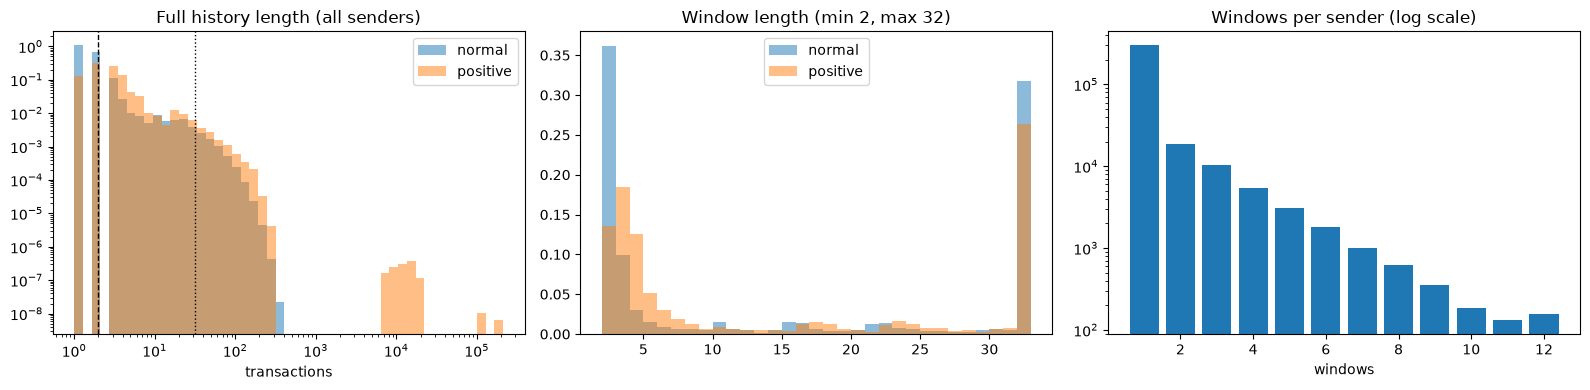

In [79]:
# --- 7.2 Class balance per split (senders and windows)
def balance(s_mask, w_mask):
    return {"senders": int(s_mask.sum()), "positive senders": int(senders.loc[s_mask, "label"].sum()),
            "positive sender rate": float(senders.loc[s_mask, "label"].mean()),
            "windows": int(w_mask.sum()), "positive windows": int(seqs.loc[w_mask, "label"].sum()),
            "positive window rate": float(seqs.loc[w_mask, "label"].mean()),
            "senders with tail": int(senders.loc[s_mask, "has_tail"].sum())}
bal = pd.DataFrame({
    "train": balance(senders.split == "train", seqs.split == "train"),
    "train (used)": balance(senders.train_keep, seqs.train_keep),
    "val": balance(senders.split == "val", seqs.split == "val"),
    "test": balance(senders.split == "test", seqs.split == "test"),
}).T
display(bal)

# --- 7.3 Sequence length distribution
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
bins_full = np.logspace(0, np.log10(sender_ntx.max()) + 0.1, 50)
ax[0].hist(sender_ntx[sender_ever == 0], bins=bins_full, alpha=0.5, density=True, label="normal")
ax[0].hist(sender_ntx[sender_ever == 1], bins=bins_full, alpha=0.5, density=True, label="positive")
ax[0].axvline(MIN_LEN, color="k", ls="--", lw=1); ax[0].axvline(MAX_LEN, color="k", ls=":", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_title("Full history length (all senders)"); ax[0].set_xlabel("transactions")

bins_w = np.arange(MIN_LEN, MAX_LEN + 2)
ax[1].hist(seqs.loc[seqs.label == 0, "length"], bins=bins_w, alpha=0.5, density=True, label="normal")
ax[1].hist(seqs.loc[seqs.label == 1, "length"], bins=bins_w, alpha=0.5, density=True, label="positive")
ax[1].set_title(f"Window length (min {MIN_LEN}, max {MAX_LEN})"); ax[1].legend()

wc = senders["n_windows"].value_counts().sort_index()
ax[2].bar(wc.index, wc.values); ax[2].set_yscale("log")
ax[2].set_title("Windows per sender (log scale)"); ax[2].set_xlabel("windows")
plt.tight_layout(); plt.show()

**Hallazgos**

- Todos los chequeos del pipeline pasan: ningún emisor en dos splits, el padding es cero, las etiquetas calzan
  con el lavado dentro de cada ventana, las transacciones están en orden temporal y los features continuos están
  estandarizados.
- Las ventanas positivas son más cortas que las normales (la mayoría de emisores positivos tiene poca historia),
  lo cual importa para Stage A (Parte 14).

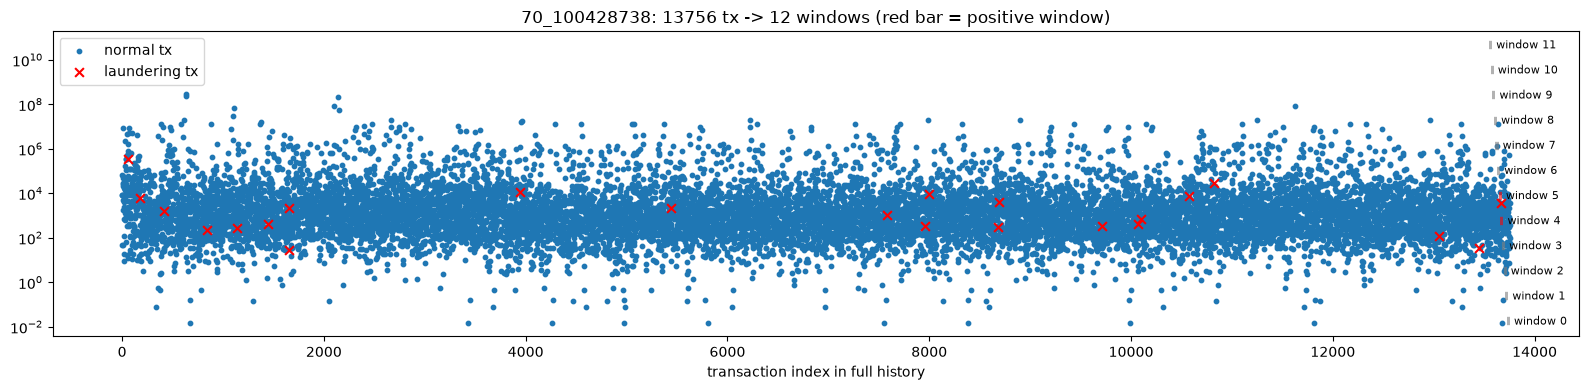

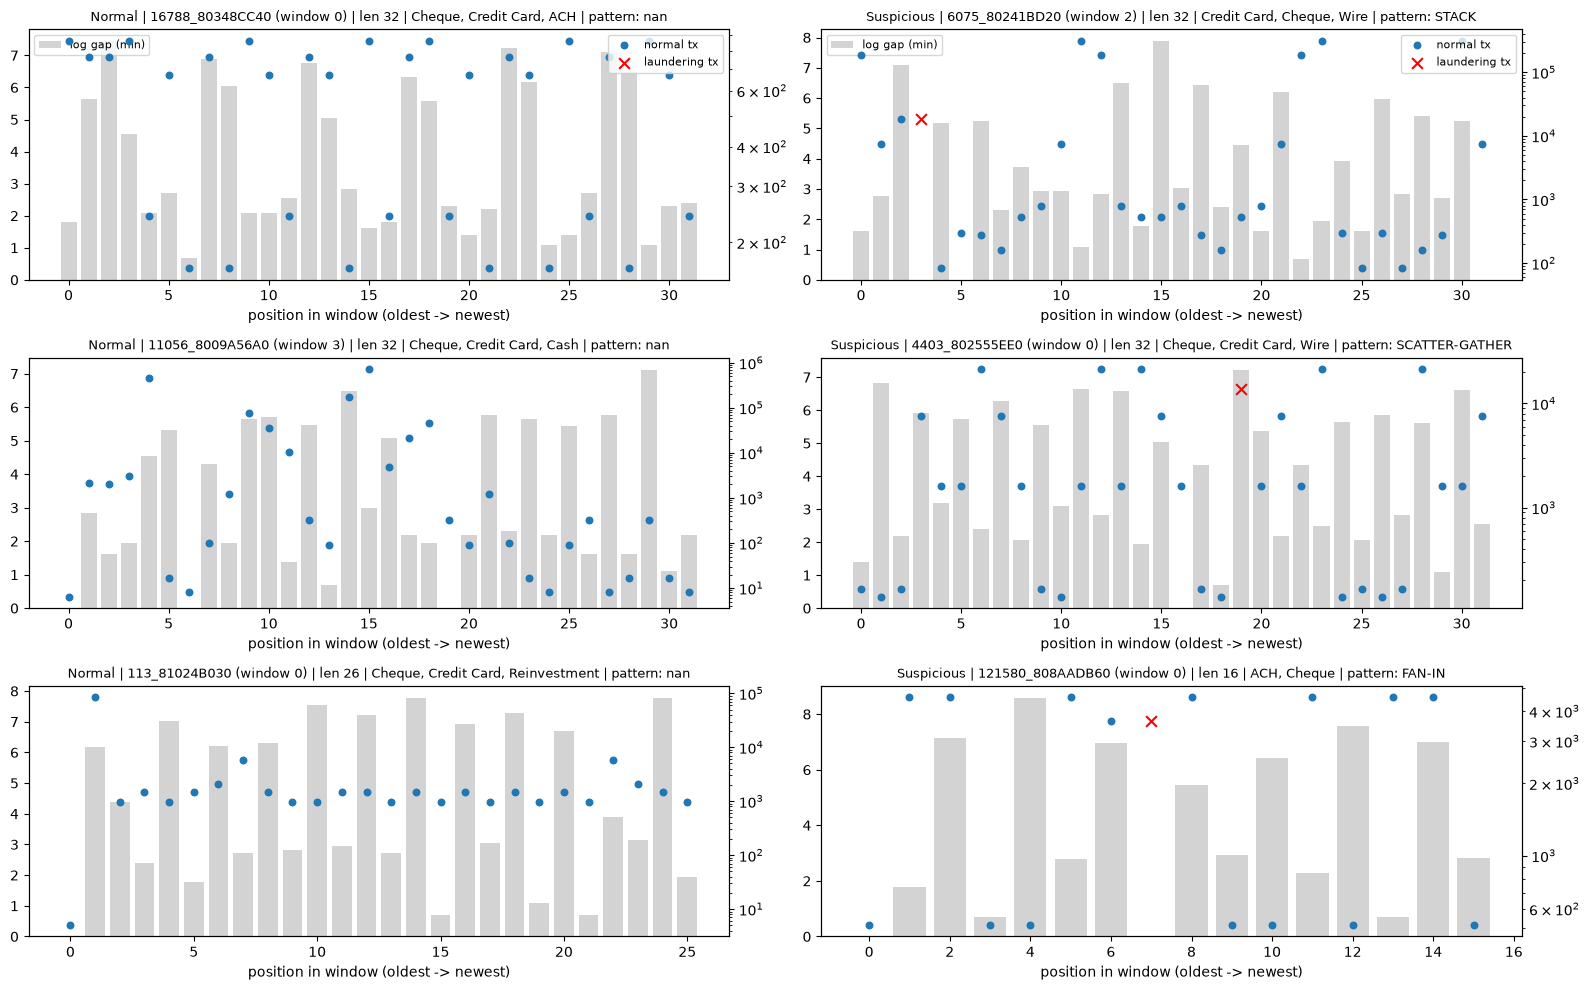

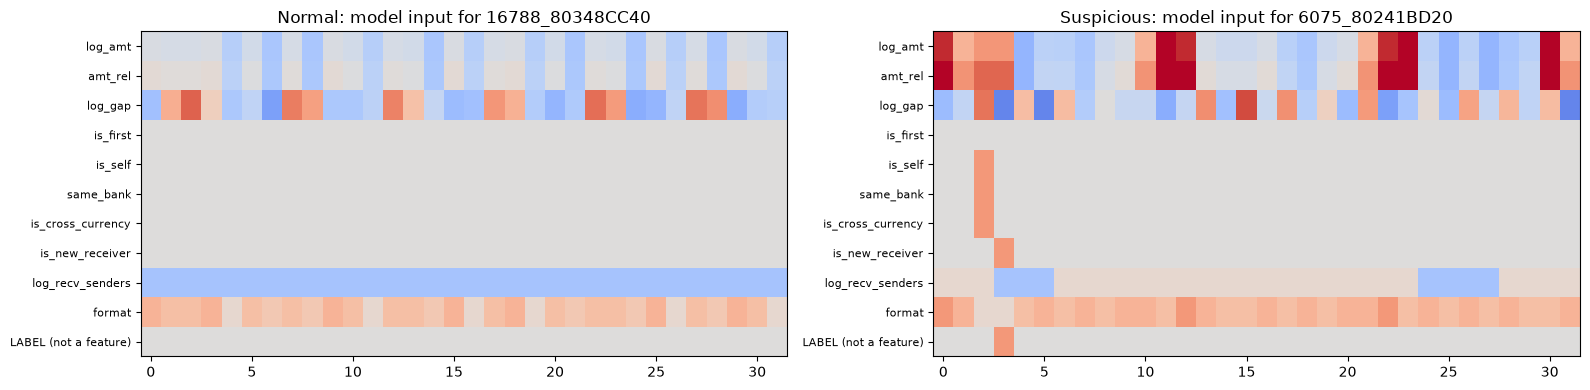

In [80]:
# --- 7.4 How sliding windows cover a long sender's history
cand = senders[(senders.n_windows >= 3)].sort_values(["label", "n_windows"], ascending=False)
if len(cand):
    sid = int(cand.index[0])
    k = int(np.flatnonzero(sender_ntx.index.to_numpy() == sid)[0])
    hist_rows = df.iloc[offsets[k]:offsets[k] + counts[k]]
    fig, ax = plt.subplots(figsize=(16, 4))
    bad = hist_rows["is_laundering"].to_numpy() == 1
    x = np.arange(len(hist_rows))
    ax.scatter(x[~bad], hist_rows["amt_usd"].to_numpy()[~bad], s=10, label="normal tx")
    ax.scatter(x[bad], hist_rows["amt_usd"].to_numpy()[bad], s=40, c="red", marker="x", label="laundering tx")
    ax.set_yscale("log")
    ymin, ymax = ax.get_ylim()
    for _, win in seqs[seqs.sender == sid].iterrows():
        y = ymin * (ymax / ymin) ** (0.05 + 0.1 * win.win_rank)
        ax.hlines(y, win.win_start, win.win_start + win.length - 1, lw=6, alpha=0.6,
                  color="red" if win.label else "gray")
        ax.text(win.win_start + win.length, y, f" window {win.win_rank}", va="center", fontsize=8)
    ax.set_title(f"{senders.loc[sid, 'sender_name']}: {counts[k]} tx -> {senders.loc[sid, 'n_windows']} windows "
                 f"(red bar = positive window)")
    ax.set_xlabel("transaction index in full history"); ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

# --- 7.5 Example sequences: 3 normal vs 3 suspicious windows (raw values, before normalization)
rng = np.random.default_rng(SEED)
def pick(label, k=3, min_len=15):
    cand = seqs[(seqs.label == label) & (seqs.length >= min_len)].index.to_numpy()
    if len(cand) < k:
        cand = seqs[seqs.label == label].index.to_numpy()
    return rng.choice(cand, size=min(k, len(cand)), replace=False)

examples = {"Normal": pick(0), "Suspicious": pick(1)}
fig, axes = plt.subplots(3, 2, figsize=(16, 10), squeeze=False)
for col, (kind, ids) in enumerate(examples.items()):
    for row in range(3):
        ax = axes[row, col]
        if row >= len(ids):
            ax.axis("off"); continue
        s = w[w["seq"] == ids[row]]
        bad = s["is_laundering"] == 1
        ax.bar(s["pos"], s["log_gap"], color="lightgray", label="log gap (min)")
        ax2 = ax.twinx()
        ax2.scatter(s.loc[~bad, "pos"], s.loc[~bad, "amt_usd"], s=22, label="normal tx")
        ax2.scatter(s.loc[bad, "pos"], s.loc[bad, "amt_usd"], s=60, c="red", marker="x", label="laundering tx")
        ax2.set_yscale("log")
        meta = seqs.loc[ids[row]]
        fmts = ", ".join(s["pay_format"].astype(str).value_counts().index[:3])
        ax.set_title(f"{kind} | {meta.sender_name} (window {meta.win_rank}) | len {meta.length} | {fmts} | "
                     f"pattern: {meta.pattern}", fontsize=9)
        ax.set_xlabel("position in window (oldest -> newest)")
        if row == 0:
            ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# feature matrix view (what the model actually sees), one normal and one suspicious
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (kind, ids) in zip(axes, examples.items()):
    i = ids[0]; n_i = int(MASK[i].sum())
    mat = np.vstack([X_num[i, :n_i].T, X_fmt[i, :n_i] / len(FMT_NAMES), Y_TX[i, :n_i]])
    ax.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_yticks(range(len(NUM_FEATURES) + 2))
    ax.set_yticklabels(NUM_FEATURES + ["format", "LABEL (not a feature)"], fontsize=8)
    ax.set_title(f"{kind}: model input for {seqs.loc[i, 'sender_name']}")
plt.tight_layout(); plt.show()

**Qué encontramos**

Describir los tres ejemplos normales y tres sospechosos: montos, gaps, formatos, dónde caen las transacciones de
lavado en la secuencia, y si se ven distintos a simple vista.

### Guardar datos procesados

In [81]:
def save_table(frame, name):
    try:
        frame.to_parquet(os.path.join(OUT_DIR, name + ".parquet"), index=False)
    except ImportError:
        frame.to_csv(os.path.join(OUT_DIR, name + ".csv"), index=False)

np.save(os.path.join(OUT_DIR, "X_num.npy"), X_num)
np.save(os.path.join(OUT_DIR, "X_fmt.npy"), X_fmt)
np.save(os.path.join(OUT_DIR, "X_cur.npy"), X_cur)
np.save(os.path.join(OUT_DIR, "MASK.npy"), MASK)
np.save(os.path.join(OUT_DIR, "Y_TX.npy"), Y_TX)
np.save(os.path.join(OUT_DIR, "TX_ID.npy"), TX_ID)
save_table(seqs.reset_index(), "windows")
save_table(senders.reset_index(), "senders")

# readable transactions for val/test windows (needed later for interpretability and the MVP)
eval_seq = seqs.index[seqs["split"].isin(["val", "test"])]
tx_view = w[w["seq"].isin(eval_seq)].copy()
tx_view["receiver_name"] = ACCOUNT_NAMES[tx_view["receiver"].to_numpy()]
tx_view["pay_format"] = tx_view["pay_format"].astype(str)
tx_view["pay_currency"] = tx_view["pay_currency"].astype(str)
save_table(tx_view[["seq", "pos", "sender", "tx_id", "ts", "receiver_name", "amt_usd", "pay_format",
                    "pay_currency", "is_laundering", "pattern", "is_tail"]], "eval_transactions")

META = {"NUM_FEATURES": NUM_FEATURES, "CONT_FEATURES": CONT_FEATURES, "NORM": NORM,
        "FMT_NAMES": FMT_NAMES, "CUR_NAMES": CUR_NAMES,
        "config": {"SEED": SEED, "MAX_LEN": MAX_LEN, "STRIDE": STRIDE,
                   "MAX_WINDOWS_PER_SENDER": MAX_WINDOWS_PER_SENDER, "MIN_LEN": MIN_LEN,
                   "TAIL_START": TAIL_START, "WR_FORMATS": WR_FORMATS,
                   "WR_ONLY_KEEP_FRAC": WR_ONLY_KEEP_FRAC, "SPLIT_FRACS": SPLIT_FRACS},
        "rates_to_usd": {k: float(v) for k, v in rates.items()}}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(META, f, indent=2)

# free the transaction tables; everything below uses the arrays + seqs/senders
del df, w, tx_view, rows, rep, pos
gc.collect()
print(sorted(os.listdir(OUT_DIR)), elapsed())

['MASK.npy', 'TX_ID.npy', 'X_cur.npy', 'X_fmt.npy', 'X_num.npy', 'Y_TX.npy', 'ablation_results.csv', 'eval_transactions.parquet', 'final_system.json', 'final_test_senders.parquet', 'idx_stage_a_train.npy', 'idx_stage_b_train.npy', 'idx_test.npy', 'idx_val.npy', 'meta.json', 'poolw_a.npy', 'senders.parquet', 'stage_a.pt', 'stage_a_history.csv', 'stage_a_scoring_candidates.csv', 'stage_b.pt', 'stage_b_test_attention.npy', 'txerr_a.npy', 'window_score_a.npy', 'windows.parquet'] [98.3 min]


## 13. Cómo medimos el éxito

Antes de modelar, las métricas. Menos del 1% de emisores son positivos, así que un modelo que nunca alerta tiene
99% de accuracy y es completamente inútil. Lo que le importa a un equipo de cumplimiento es: **si solo podemos
revisar un número limitado de alertas, cuántos casos reales hay ahí, y cuántos casos se nos escapan?**

Todo se evalúa **por emisor** (la unidad que recibe una alerta), nunca por ventana, porque ventanas solapadas del
mismo emisor no son independientes.

| Métrica | Qué pregunta responde | Rol |
|---|---|---|
| **PR-AUC** (average precision) | Qué tan buena es toda la ranking de emisores poniendo positivos primero? | **Métrica principal.** La selección de modelo se hace con esto en validación. Un ranking aleatorio da la tasa positiva (~0.0094), así que también reportamos el lift sobre aleatorio. |
| **Recall @ 1% y @ 5% de emisores alertados** | Si el equipo revisa el 1% (≈516) o 5% (≈2,580) más riesgoso, qué fracción de lavadores encuentran? | **Métrica operativa.** Se traduce directo a carga de trabajo para el reporte. |
| **Precision @ 100** | De las top 100 alertas, cuántas son reales? | Vista de cola de un analista. Sistemas basados en reglas corren a 1–5% de precision (95–99% falsos positivos, según el enunciado). |
| Precision / recall / F1 en un umbral | Qué pasa en un corte concreto, elegido en validación (mejor F1)? | Necesario para desplegar, pero depende del umbral elegido. |
| ROC-AUC | Probabilidad de que un positivo aleatorio quede rankeado sobre un negativo aleatorio | Se muestra por completitud; se ve bien incluso para modelos débiles cuando dominan los negativos. |

Los números de test vienen con **intervalos bootstrap del 95%** (resampleando emisores de test), para no leer
ruido como progreso.

In [82]:
def average_precision(y, s):
    o = np.argsort(-s, kind="mergesort"); ys = y[o]
    precision = np.cumsum(ys) / np.arange(1, len(ys) + 1)
    return float((precision * ys).sum() / max(ys.sum(), 1))

def roc_auc(y, s):
    ranks = pd.Series(s).rank().to_numpy(); n1 = y.sum(); n0 = len(y) - n1
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / max(n1 * n0, 1))

def recall_at_budget(y, s, frac):
    k = max(1, int(round(len(y) * frac))); o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].sum() / max(y.sum(), 1))

def precision_at_k(y, s, k=100):
    o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].mean())

def best_f1_threshold(y, s):
    o = np.argsort(-s, kind="mergesort"); ys, ss = y[o], s[o]
    tp = np.cumsum(ys); k = np.arange(1, len(ys) + 1)
    prec, rec = tp / k, tp / max(ys.sum(), 1)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return float(ss[int(f1.argmax())])

def evaluate(y, s, thr=None):
    y = np.asarray(y).astype(np.int64); s = np.asarray(s, dtype=np.float64)
    out = {"PR-AUC": average_precision(y, s)}
    out["lift vs random"] = out["PR-AUC"] / max(y.mean(), 1e-12)
    out.update({"ROC-AUC": roc_auc(y, s), "P@100": precision_at_k(y, s, 100),
                "recall @1%": recall_at_budget(y, s, 0.01), "recall @5%": recall_at_budget(y, s, 0.05)})
    if thr is not None:
        pred = s >= thr; tp = int((pred & (y == 1)).sum())
        p, r = tp / max(pred.sum(), 1), tp / max(y.sum(), 1)
        out.update({"precision @thr": p, "recall @thr": r, "F1 @thr": 2 * p * r / max(p + r, 1e-12),
                    "alert rate @thr": float(pred.mean())})
    return out

def bootstrap_ci(y, s, fn, n_boot=200, seed=SEED):
    rng = np.random.default_rng(seed); y = np.asarray(y); s = np.asarray(s, dtype=np.float64)
    vals = [fn(y[i], s[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(n_boot))]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

# sender-level view of any per-window score
SENDER_OF = seqs["sender"].to_numpy()
LEN = MASK.sum(1)
def to_senders(window_scores, idx, agg="max"):
    """window_scores covers ALL windows (global index); idx selects the windows to aggregate."""
    return pd.Series(np.asarray(window_scores)[idx], index=SENDER_OF[idx]).groupby(level=0).agg(agg)

def local_to_senders(values, idx, agg="max"):
    """values[i] belongs to window idx[i] (e.g. predictions made only on the validation windows)."""
    return pd.Series(np.asarray(values), index=SENDER_OF[idx]).groupby(level=0).agg(agg)

VAL_SENDERS = np.unique(SENDER_OF[SETS["val"]])
TEST_SENDERS = np.unique(SENDER_OF[SETS["test"]])
Y_VAL = senders.loc[VAL_SENDERS, "label"].to_numpy()
Y_TEST = senders.loc[TEST_SENDERS, "label"].to_numpy()
print(f"Validation: {len(VAL_SENDERS):,} senders ({Y_VAL.sum()} positive) | "
      f"test: {len(TEST_SENDERS):,} senders ({Y_TEST.sum()} positive)")

Validation: 51,637 senders (487 positive) | test: 51,637 senders (486 positive)


## 14. Stage A: aprender cómo se ve lo normal

### La idea

Stage A nunca ve una etiqueta. Se entrena solo con ventanas de emisores que nunca lavaron, con una tarea: leer
una ventana, comprimirla en 32 números, y reconstruir toda la ventana desde esos 32 números. Para hacerlo bien
tiene que aprender cómo son las secuencias típicas (montos usuales, ritmos, formatos, cada cuánto cambia el
receptor). Una ventana distinta a los datos de entrenamiento se reconstruye mal, y **ese error de reconstrucción
es el puntaje de anomalía**. Esta es la parte de "aprender lo normal antes de aprender lo sospechoso" del
enunciado.

### Cómo funciona la arquitectura, paso a paso

```
ventana (B, 32 transacciones, 9 features numéricos + formato + moneda)
  │
  ├─ 1. Embedding de transacción: features numéricos → capa lineal, formato y moneda → embeddings aprendidos,
  │                              + un embedding de posición aprendido; se suman en un vector de 64-d por tx
  ├─ 2. Encoder Transformer ×2: self-attention + feed-forward, con conexiones residuales y LayerNorm
  ├─ 3. Attention pooling:      un promedio ponderado aprendido de los 32 vectores → un vector de 64-d
  ├─ 4. Cuello de botella:      capa lineal → z (32 números)          ← todo lo que sabrá el decoder
  │
  └─ Decoder: z + una "consulta de posición" aprendida por slot → 1 capa de self-attention sobre los slots
              → para cada slot: los 9 features numéricos, el formato y la moneda
```

1. **Embedding.** Números y categorías viven en espacios distintos, así que cada uno tiene su propia proyección
   al mismo espacio de 64-d. El embedding de posición le dice al modelo el orden (1ra, 2da, ... transacción de la
   ventana).
2. **Self-attention** es el núcleo. Para cada transacción, la capa construye una *query* ("qué estoy buscando?")
   y cada transacción construye una *key* ("qué contengo?") y un *value* ("qué paso?"). La similitud de la query
   con cada key, pasada por un softmax, dice cuánto aporta cada otra transacción a la nueva representación de
   esta. Con 4 heads el modelo puede buscar relaciones distintas a la vez, por ejemplo "pagos al mismo receptor",
   "pagos separados por pocos minutos" o "montos parecidos". Las posiciones de padding se enmascaran para que
   reciban atención cero. La capa feed-forward transforma cada transacción por su cuenta; las conexiones
   residuales y LayerNorm mantienen el entrenamiento estable.
3. **Attention pooling** le da un puntaje a cada transacción, convierte los puntajes en pesos que suman 1 y
   promedia los vectores con esos pesos. Da un vector por ventana y **un peso por transacción**, que es lo que
   usan el heatmap y el análisis de interpretabilidad.
4. **Cuello de botella y decoder.** El decoder solo recibe `z` más la posición que tiene que llenar; nunca ve el
   input. Si pudiera, copiaría cualquier cosa, anomalías incluidas, y el error no significaría nada. Con 32
   números para hasta 32 transacciones × 11 inputs, el modelo se ve forzado a quedarse con lo típico y botar el
   resto.
5. **Loss.** Error cuadrático en los features numéricos más cross-entropy en formato y moneda, promediado solo
   sobre transacciones reales. El promedio de una ventana es su error; los errores por transacción también se
   guardan.

### Por qué un Transformer y no un LSTM/GRU o una CNN

| | Transformer (elegido) | LSTM / GRU | CNN 1D |
|---|---|---|---|
| Cómo lee la ventana | Cada transacción mira directamente a todas las demás | Una transacción a la vez, cargando un vector de memoria | Vecindarios locales, ampliados apilando capas |
| Relaciones entre transacciones lejanas (ej. el pago 1 y el 25 al mismo receptor) | Un paso | Debe sobrevivir en memoria a lo largo de todos los pasos intermedios | Necesita suficientes capas para conectarlas |
| Timing irregular | Orden vía embedding de posición, timing vía el feature de gap | Igual (feature de gap) | Asume pasos parejos en el tiempo, que las transacciones no son |
| Explicación por transacción | El attention pooling la da directo | Necesita una capa de atención agregada | Necesita una capa de atención agregada |
| Velocidad de entrenamiento en GPU | Todas las posiciones en paralelo; con 32 transacciones el costo cuadrático es chico | Secuencial, más lento | Rápido |
| Puntos débiles | Más hiperparámetros; necesita masking y un cuello de botella real | Puede difuminar transacciones tempranas; más lento | Mal fit para secuencias de eventos |

La versión honesta: con ventanas de solo 32 transacciones, un LSTM/GRU no es mala opción, y la diferencia en
accuracy puede ser chica. Elegimos el Transformer porque el problema es sobre **relaciones entre transacciones**
(receptores repetidos, ráfagas, montos partidos), que el self-attention modela directamente; porque entrena en
paralelo, lo cual importa con el presupuesto de 30 minutos; y porque el attention pooling da la explicación por
transacción que pide el enunciado. No lo asumimos sin más: **la Parte 15 entrena un encoder GRU bajo exactamente
las mismas condiciones** y compara.

*(Agregar las semanas del curso donde se vio atención, Transformers y autoencoders.)*

In [83]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU (will be slow)")

CFG_A = dict(d_model=64, n_heads=4, n_layers=2, d_ff=128, z_dim=32, dec_layers=1, dropout=0.1,
             lr=1e-3, weight_decay=1e-4, batch_size=1024, max_epochs=25, patience=3,
             w_cat=0.5, max_train=250_000, max_val=30_000)
N_FMT, N_CUR = len(FMT_NAMES), len(CUR_NAMES)

Device: cuda | NVIDIA GeForce RTX 4070 SUPER


In [84]:
class TransactionEmbedding(nn.Module):
    """Numeric features + format/currency embeddings + learned position -> one d_model vector per tx."""
    def __init__(self, n_num, n_fmt, n_cur, d_model, max_len):
        super().__init__()
        self.num_proj = nn.Linear(n_num, d_model)
        self.fmt_emb = nn.Embedding(n_fmt + 1, d_model, padding_idx=0)
        self.cur_emb = nn.Embedding(n_cur + 1, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x_num, x_fmt, x_cur):
        pos = torch.arange(x_num.size(1), device=x_num.device)
        h = self.num_proj(x_num) + self.fmt_emb(x_fmt) + self.cur_emb(x_cur) + self.pos_emb(pos)[None]
        return self.norm(h)


class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product self-attention that also returns the attention weights."""
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):                      # x: (B, L, D); pad_mask: (B, L) True = padding
        B, L, D = x.shape
        q, k, v = self.qkv(x).view(B, L, 3, self.h, self.d_k).permute(2, 0, 3, 1, 4)   # each (B, h, L, d_k)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_k)                        # (B, h, L, L)
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask[:, None, None, :], float("-inf"))    # nobody attends to padding
        attn = torch.softmax(scores, dim=-1)
        out = (self.drop(attn) @ v).transpose(1, 2).reshape(B, L, D)
        return self.out(out), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer block: self-attention + feed-forward, both with residuals."""
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        a, weights = self.attn(self.ln1(x), pad_mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, weights


class AttentionPooling(nn.Module):
    """Learned weighted average over transactions -> one vector per sequence + one weight per transaction."""
    def __init__(self, d_model, d_attn=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(d_model, d_attn), nn.Tanh(), nn.Linear(d_attn, 1))

    def forward(self, h, pad_mask):
        s = self.score(h).squeeze(-1).masked_fill(pad_mask, float("-inf"))
        a = torch.softmax(s, dim=-1)                          # (B, L), sums to 1 over real transactions
        return (a.unsqueeze(-1) * h).sum(1), a


class SequenceEncoder(nn.Module):
    """Shared between Stage A and Stage B."""
    def __init__(self, n_num, n_fmt, n_cur, max_len, d_model, n_heads, n_layers, d_ff, z_dim, dropout):
        super().__init__()
        self.embed = TransactionEmbedding(n_num, n_fmt, n_cur, d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_ln = nn.LayerNorm(d_model)
        self.pool = AttentionPooling(d_model)
        self.to_z = nn.Linear(d_model, z_dim)

    def forward(self, x_num, x_fmt, x_cur, valid):
        pad = ~valid
        h = self.embed(x_num, x_fmt, x_cur)
        self_attn = []
        for layer in self.layers:
            h, wts = layer(h, pad)
            self_attn.append(wts)
        h = self.final_ln(h)
        pooled, pool_w = self.pool(h, pad)
        return {"z": self.to_z(pooled), "h": h, "pooled": pooled, "pool_weights": pool_w, "self_attn": self_attn}


class SequenceDecoder(nn.Module):
    """Rebuilds the sequence from z only: z + position query -> self-attention over positions -> features."""
    def __init__(self, z_dim, d_model, n_heads, d_ff, n_layers, dropout, max_len, n_num, n_fmt, n_cur):
        super().__init__()
        self.from_z = nn.Linear(z_dim, d_model)
        self.pos_query = nn.Embedding(max_len, d_model)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.num_head = nn.Linear(d_model, n_num)
        self.fmt_head = nn.Linear(d_model, n_fmt + 1)
        self.cur_head = nn.Linear(d_model, n_cur + 1)

    def forward(self, z, length):
        pos = torch.arange(length, device=z.device)
        h = self.from_z(z)[:, None, :] + self.pos_query(pos)[None]     # (B, L, D), no access to the input
        for layer in self.layers:
            h, _ = layer(h)
        h = self.ln(h)
        return self.num_head(h), self.fmt_head(h), self.cur_head(h)


class SequenceAutoencoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = SequenceEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, cfg["d_model"], cfg["n_heads"],
                                       cfg["n_layers"], cfg["d_ff"], cfg["z_dim"], cfg["dropout"])
        self.decoder = SequenceDecoder(cfg["z_dim"], cfg["d_model"], cfg["n_heads"], cfg["d_ff"],
                                       cfg["dec_layers"], cfg["dropout"], MAX_LEN, F_NUM, N_FMT, N_CUR)

    def forward(self, x_num, x_fmt, x_cur, valid):
        enc = self.encoder(x_num, x_fmt, x_cur, valid)
        return enc, self.decoder(enc["z"], x_num.size(1))


def reconstruction_errors(rec, x_num, x_fmt, x_cur, valid, w_cat):
    """Per-transaction error (B, L), zero on padding, and per-sequence mean error (B,)."""
    rec_num, rec_fmt, rec_cur = rec
    err = ((rec_num - x_num) ** 2).mean(-1)
    err = err + w_cat * (F.cross_entropy(rec_fmt.transpose(1, 2), x_fmt, reduction="none")
                         + F.cross_entropy(rec_cur.transpose(1, 2), x_cur, reduction="none"))
    per_tx = err * valid
    return per_tx, per_tx.sum(1) / valid.sum(1)


model_a = SequenceAutoencoder(CFG_A).to(DEVICE)
print(f"Stage A parameters: {sum(p.numel() for p in model_a.parameters()):,}")

Stage A parameters: 117,634


**Tests de cordura antes de entrenar:** shapes y un loss finito, el padding no debe cambiar `z`, y un modelo
recién inicializado debe poder sobreajustar un batch chico. En nuestra corrida los tres pasaron (diferencia de
padding exactamente 0, loss de overfit 3.45 → 0.91).

In [85]:
def to_device(idx):
    """Index the numpy arrays and move one set of sequences to the device."""
    idx = np.asarray(idx)
    return (torch.from_numpy(X_num[idx]).to(DEVICE),
            torch.from_numpy(X_fmt[idx].astype(np.int64)).to(DEVICE),
            torch.from_numpy(X_cur[idx].astype(np.int64)).to(DEVICE),
            torch.from_numpy(MASK[idx]).to(DEVICE))

# --- Sanity test 1: shapes and a finite loss on a small batch
short = np.flatnonzero(seqs["length"].to_numpy() < MAX_LEN // 2)[:128]
xb = to_device(short)
model_a.eval()
with torch.no_grad():
    enc, rec = model_a(*xb)
    per_tx, per_seq = reconstruction_errors(rec, *xb, CFG_A["w_cat"])
assert enc["z"].shape == (len(short), CFG_A["z_dim"])
assert rec[0].shape == xb[0].shape and torch.isfinite(per_seq).all()
assert torch.allclose(enc["pool_weights"].sum(1), torch.ones(len(short), device=DEVICE), atol=1e-4)
assert (enc["pool_weights"][~xb[3]] == 0).all(), "padding received pooling weight"
print("Test 1 passed: shapes, finite loss, pooling weights sum to 1 and ignore padding")

# --- Sanity test 2: changing padded positions must not change z (masking works)
with torch.no_grad():
    xn, xf, xc, v = [t.clone() for t in xb]
    pad = ~v
    xn[pad] = torch.randn_like(xn)[pad] * 10
    xf[pad] = torch.randint(1, N_FMT + 1, xf.shape, device=DEVICE)[pad]
    xc[pad] = torch.randint(1, N_CUR + 1, xc.shape, device=DEVICE)[pad]
    diff = (model_a.encoder(xn, xf, xc, v)["z"] - enc["z"]).abs().max().item()
assert diff < 1e-4, f"padding leaks into z (max diff {diff})"
print(f"Test 2 passed: padding does not affect z (max diff {diff:.2e})")

# --- Sanity test 3: a fresh model can overfit 64 sequences (the training loop can learn)
tiny = SequenceAutoencoder(CFG_A).to(DEVICE)
opt_t = torch.optim.AdamW(tiny.parameters(), lr=3e-3)
xb_t = to_device(np.flatnonzero(seqs["train_keep"].to_numpy() & (seqs["ever_label"].to_numpy() == 0))[:64])
losses = []
tiny.train()
for step in range(200):
    _, rec = tiny(*xb_t)
    loss = reconstruction_errors(rec, *xb_t, CFG_A["w_cat"])[1].mean()
    opt_t.zero_grad(); loss.backward(); opt_t.step()
    losses.append(loss.item())
print(f"Test 3: overfit loss {losses[0]:.3f} -> {losses[-1]:.3f}")
if losses[-1] > 0.5 * losses[0]:
    print("WARNING: loss barely dropped on a tiny batch; check learning rate or model before full training")
del tiny, opt_t, xb_t, xb

Test 1 passed: shapes, finite loss, pooling weights sum to 1 and ignore padding
Test 2 passed: padding does not affect z (max diff 0.00e+00)
Test 3: overfit loss 3.510 -> 0.961


**Entrenamiento.** AdamW con un epoch de warmup y decay coseno, gradient clipping, y early stopping sobre el
loss de reconstrucción de ventanas normales de validación. En la corrida anterior el loss de validación seguía
mejorando un poco en el epoch 20 (0.3049) sin señales de overfitting, así que el límite ahora es 25 epochs
(~10 s cada uno en una T4).

Stage A train: 250,000 windows of normal senders | early-stopping val: 30,000 windows
epoch  1 | train 1.8355 | val(normal) 0.7148 * | 4s [98.4 min]
epoch  2 | train 0.6483 | val(normal) 0.4771 * | 4s [98.5 min]
epoch  3 | train 0.5370 | val(normal) 0.4373 * | 4s [98.5 min]
epoch  4 | train 0.5028 | val(normal) 0.4155 * | 4s [98.6 min]
epoch  5 | train 0.4785 | val(normal) 0.3941 * | 4s [98.7 min]
epoch  6 | train 0.4577 | val(normal) 0.3793 * | 4s [98.7 min]
epoch  7 | train 0.4415 | val(normal) 0.3654 * | 4s [98.8 min]
epoch  8 | train 0.4266 | val(normal) 0.3509 * | 4s [98.9 min]
epoch  9 | train 0.4116 | val(normal) 0.3389 * | 4s [98.9 min]
epoch 10 | train 0.3984 | val(normal) 0.3277 * | 4s [99.0 min]
epoch 11 | train 0.3878 | val(normal) 0.3211 * | 4s [99.1 min]
epoch 12 | train 0.3807 | val(normal) 0.3152 * | 4s [99.1 min]
epoch 13 | train 0.3749 | val(normal) 0.3111 * | 4s [99.2 min]
epoch 14 | train 0.3699 | val(normal) 0.3065 * | 4s [99.2 min]
epoch 15 | train 0.3650 | val(no

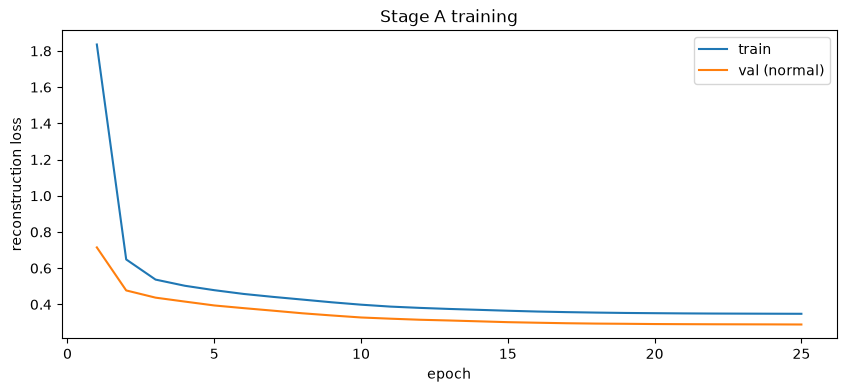

In [86]:
# --- Training data: training senders that NEVER laundered (normal only)
rng = np.random.default_rng(SEED)
tr_a = SETS["stage_a_train"].copy()
if len(tr_a) > CFG_A["max_train"]:
    tr_a = np.sort(rng.choice(tr_a, CFG_A["max_train"], replace=False))
va_a = np.flatnonzero((seqs["split"] == "val").to_numpy() & (seqs["ever_label"].to_numpy() == 0))
if len(va_a) > CFG_A["max_val"]:
    va_a = np.sort(rng.choice(va_a, CFG_A["max_val"], replace=False))
assert seqs.loc[tr_a, "ever_label"].sum() == 0, "Stage A training set contains laundering senders"
print(f"Stage A train: {len(tr_a):,} windows of normal senders | early-stopping val: {len(va_a):,} windows")

TR = to_device(tr_a)      # whole training set on the GPU: much faster than a DataLoader for this size
VA = to_device(va_a)

def eval_loss(model, data, bs=2048):
    model.eval(); total = 0.0
    with torch.no_grad():
        for s in range(0, data[0].size(0), bs):
            b = [t[s:s + bs] for t in data]
            total += reconstruction_errors(model(*b)[1], *b, CFG_A["w_cat"])[1].sum().item()
    return total / data[0].size(0)

opt = torch.optim.AdamW(model_a.parameters(), lr=CFG_A["lr"], weight_decay=CFG_A["weight_decay"])
steps_per_epoch = math.ceil(len(tr_a) / CFG_A["batch_size"])
total_steps, warmup = CFG_A["max_epochs"] * steps_per_epoch, steps_per_epoch
def lr_lambda(step):                      # linear warmup for one epoch, then cosine decay
    if step < warmup:
        return (step + 1) / warmup
    p = min(1.0, (step - warmup) / max(1, total_steps - warmup))
    return max(0.05, 0.5 * (1 + math.cos(math.pi * p)))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

history, best, best_state, bad_epochs = [], float("inf"), None, 0
gen = torch.Generator().manual_seed(SEED)
for epoch in range(1, CFG_A["max_epochs"] + 1):
    t_ep = time.time(); model_a.train(); run = 0.0
    order = torch.randperm(len(tr_a), generator=gen).to(DEVICE)
    for s in range(0, len(tr_a), CFG_A["batch_size"]):
        bi = order[s:s + CFG_A["batch_size"]]
        b = [t[bi] for t in TR]
        loss = reconstruction_errors(model_a(*b)[1], *b, CFG_A["w_cat"])[1].mean()
        opt.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        opt.step(); sched.step()
        run += loss.item() * len(bi)
    tr_loss, va_loss = run / len(tr_a), eval_loss(model_a, VA)
    history.append({"epoch": epoch, "train": tr_loss, "val_normal": va_loss})
    improved = va_loss < best - 1e-4
    if improved:
        best, bad_epochs = va_loss, 0
        best_state = {k: v.detach().clone() for k, v in model_a.state_dict().items()}
    else:
        bad_epochs += 1
    print(f"epoch {epoch:2d} | train {tr_loss:.4f} | val(normal) {va_loss:.4f} {'*' if improved else ''} "
          f"| {time.time() - t_ep:.0f}s {elapsed()}")
    if bad_epochs >= CFG_A["patience"]:
        print("Early stopping."); break

model_a.load_state_dict(best_state)
del TR, VA; gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

hist = pd.DataFrame(history)
plt.plot(hist.epoch, hist.train, label="train"); plt.plot(hist.epoch, hist.val_normal, label="val (normal)")
plt.xlabel("epoch"); plt.ylabel("reconstruction loss"); plt.legend(); plt.title("Stage A training"); plt.show()

### Puntuar cada ventana

In [87]:
@torch.no_grad()
def score_windows(model, idx, bs=4096):
    model.eval()
    scores, per_tx_all, pool_all = [], [], []
    for s in range(0, len(idx), bs):
        b = to_device(idx[s:s + bs])
        enc, rec = model(*b)
        per_tx, per_seq = reconstruction_errors(rec, *b, CFG_A["w_cat"])
        scores.append(per_seq.cpu()); per_tx_all.append(per_tx.cpu()); pool_all.append(enc["pool_weights"].cpu())
    return torch.cat(scores).numpy(), torch.cat(per_tx_all).numpy(), torch.cat(pool_all).numpy()

SCORE_A, TXERR_A, POOLW_A = score_windows(model_a, np.arange(N))
print(f"Scored {N:,} windows {elapsed()}")

Scored 439,590 windows [100.0 min]


### El problema del largo

En la versión anterior, el puntaje del emisor era el error medio de reconstrucción de la ventana, tomando el
máximo sobre las ventanas de un emisor. Llegó a 2.6× el PR-AUC aleatorio en test (0.025 vs 0.0094), pero el
análisis mostró qué estaba midiendo en realidad:

- Emisores normales con ≤5 transacciones se marcaban 0.04% de las veces; emisores normales con más de 128
  transacciones, **42%** de las veces.
- Emisores normales con 1 ventana se marcaban 0.3% de las veces, con 4 ventanas 21%.

Así que el puntaje era sobre todo "cuánta actividad tiene este emisor": ventanas más largas cargan más
información de la que 32 números pueden guardar, así que siempre se reconstruyen peor, y tomar el máximo sobre
más ventanas suma más chances de salir alto. Los emisores positivos suelen ser cortos, así que se veían normales.
Por otro lado, **para los positivos detectados, la transacción con mayor error era una transacción de lavado
real el 63% de las veces (aleatorio: 6%)**, así que la señal por transacción sí sirve. El gráfico de abajo
muestra el efecto en ventanas normales de entrenamiento.

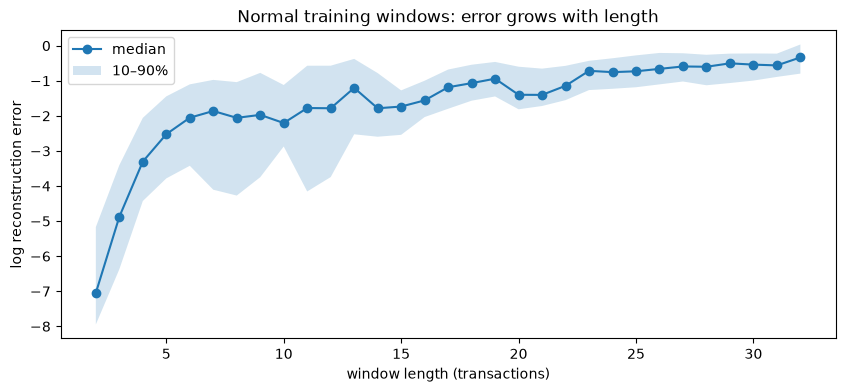

In [88]:
ref = SETS["stage_a_train"]
by_len = pd.DataFrame({"length": LEN[ref], "log error": np.log(SCORE_A[ref] + 1e-6)}).groupby("length")["log error"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_len.median().index, by_len.median().values, marker="o", label="median")
ax.fill_between(by_len.quantile(.1).index, by_len.quantile(.1).values, by_len.quantile(.9).values, alpha=.2, label="10–90%")
ax.set_xlabel("window length (transactions)"); ax.set_ylabel("log reconstruction error")
ax.set_title("Normal training windows: error grows with length"); ax.legend(); plt.show()

**Qué hacemos al respecto**

**Comparar cada ventana con ventanas normales del mismo largo.** Para cada largo, tomamos los log-errores de las
ventanas normales de entrenamiento de Stage A y calculamos su media y desviación estándar. El puntaje de una
ventana pasa a ser cuántas desviaciones estándar está sobre lo normal-para-su-largo. Esto no usa etiquetas.
Largos con pocas ventanas toman prestado de largos vecinos.

También probamos dos ideas más y **dejamos que decida validación**:
- **Error top-3** en vez de error medio: el promedio de las 3 transacciones peor reconstruidas, para que una o
  dos transacciones de lavado no se diluyan entre 30 normales.
- **Media sobre las ventanas de un emisor** en vez de máximo, que quita el efecto "más ventanas, más chances".

In [89]:
def length_normalize(raw, ref_idx, min_count=500):
    """log(raw) standardized by the mean/std of normal reference windows of the same length."""
    lr = np.log(np.asarray(raw) + 1e-6)
    mu, sd = np.zeros(MAX_LEN + 1), np.ones(MAX_LEN + 1)
    ref_len, ref_val = LEN[ref_idx], lr[ref_idx]
    for L in range(1, MAX_LEN + 1):
        k = 0
        while True:
            sel = (ref_len >= L - k) & (ref_len <= L + k)
            if sel.sum() >= min_count or k >= MAX_LEN:
                break
            k += 1
        if sel.any():
            mu[L], sd[L] = ref_val[sel].mean(), ref_val[sel].std() + 1e-6
    return (lr - mu[LEN]) / sd[LEN]

err = np.where(MASK, TXERR_A, np.nan)
top3 = -np.sort(-np.nan_to_num(err, nan=-np.inf), axis=1)[:, :3]
top3 = np.nanmean(np.where(np.isfinite(top3), top3, np.nan), axis=1)

WINDOW_CANDIDATES = {
    "mean error (previous)": SCORE_A,
    "mean error, length-normalized": length_normalize(SCORE_A, SETS["stage_a_train"]),
    "top-3 error, length-normalized": length_normalize(top3, SETS["stage_a_train"]),
}
cand_rows = []
for wname, ws in WINDOW_CANDIDATES.items():
    for agg in ["max", "mean"]:
        sv = to_senders(ws, SETS["val"], agg).reindex(VAL_SENDERS).to_numpy()
        cand_rows.append({"window score": wname, "over a sender's windows": agg, **evaluate(Y_VAL, sv)})
cand_tbl = pd.DataFrame(cand_rows).sort_values("PR-AUC", ascending=False)
display(cand_tbl)

best = cand_tbl.iloc[0]
A_WINDOW_NAME, A_AGG = best["window score"], best["over a sender's windows"]
WINDOW_SCORE_A = WINDOW_CANDIDATES[A_WINDOW_NAME]
SA_VAL = to_senders(WINDOW_SCORE_A, SETS["val"], A_AGG).reindex(VAL_SENDERS).to_numpy()
SA_TEST = to_senders(WINDOW_SCORE_A, SETS["test"], A_AGG).reindex(TEST_SENDERS).to_numpy()
THR_A = best_f1_threshold(Y_VAL, SA_VAL)
print(f"Chosen on validation: {A_WINDOW_NAME}, {A_AGG} over windows | threshold {THR_A:.3f}")
display(pd.DataFrame({"val": evaluate(Y_VAL, SA_VAL, THR_A), "test": evaluate(Y_TEST, SA_TEST, THR_A)}))

,window score,over a sender's windows,PR-AUC,lift vs random,ROC-AUC,P@100,recall @1%,recall @5%
4,"top-3 error, length-normalized",max,0.1314,13.9325,0.7706,0.4800,0.2177,0.4517
5,"top-3 error, length-normalized",mean,0.1283,13.6062,0.7584,0.4800,0.2238,0.4251
2,"mean error, length-normalized",max,0.1167,12.3733,0.7474,0.4800,0.2053,0.3737
3,"mean error, length-normalized",mean,0.1155,12.2448,0.7392,0.4800,0.2074,0.3634
1,mean error (previous),mean,0.0481,5.0954,0.7560,0.1300,0.1088,0.2916
0,mean error (previous),max,0.0430,4.5624,0.7542,0.1200,0.1006,0.2813


Chosen on validation: top-3 error, length-normalized, max over windows | threshold 2.699


,val,test
PR-AUC,0.1314,0.1132
lift vs random,13.9325,12.0261
ROC-AUC,0.7706,0.7619
P@100,0.4800,0.4200
recall @1%,0.2177,0.1914
recall @5%,0.4517,0.4259
precision @thr,0.1963,0.1606
recall @thr,0.2608,0.2099
F1 @thr,0.2240,0.1820
alert rate @thr,0.0125,0.0123


**Qué encontramos**

Completar con las tablas de arriba: qué puntuación ganó en validación, su PR-AUC y recall @5% comparado con la
puntuación anterior, y los números de test.

### ¿Se arregló el problema del largo?

Tasas de alerta cuando se alerta al top 5% de emisores de test, por largo de historia y número de ventanas, para
el puntaje anterior y el elegido. Idealmente los emisores normales tienen una tasa de alerta parecida sin
importar el largo.

In [90]:
def alert_top(s, frac=0.05):
    k = int(round(len(s) * frac)); a = np.zeros(len(s), bool); a[np.argsort(-s, kind="mergesort")[:k]] = True
    return a

prev_test = to_senders(SCORE_A, SETS["test"], "max").reindex(TEST_SENDERS).to_numpy()
t = senders.loc[TEST_SENDERS, ["label", "n_tx_total", "n_windows", "has_tail", "pattern"]].copy()
t["alert previous"], t["alert chosen"] = alert_top(prev_test), alert_top(SA_TEST)
t["history"] = pd.cut(t["n_tx_total"], [MIN_LEN - 1, 5, 10, 20, MAX_LEN, 128, np.inf])
t["windows"] = pd.cut(t["n_windows"], [0, 1, 2, 4, MAX_WINDOWS_PER_SENDER])
display(t.groupby(["history", "label"], observed=True)[["alert previous", "alert chosen"]].mean().unstack())
display(t.groupby(["windows", "label"], observed=True)[["alert previous", "alert chosen"]].mean().unstack())
display(t.groupby(["label", "has_tail"])[["alert chosen"]].agg(["size", "mean"]))
display(t[t.label == 1].assign(pattern=lambda d: d["pattern"].fillna("(no typology)"))
          .groupby("pattern")["alert chosen"].agg(positives="size", recall="mean").sort_values("recall", ascending=False))

alert previous        alert chosen       
label                      0      1            0      1
history                                                
(1.0, 5.0]            0.0002 0.1155       0.0483 0.4260
(5.0, 10.0]           0.0047 0.2667       0.0179 0.4444
(10.0, 20.0]          0.0130 0.1875       0.0318 0.5000
(20.0, 32.0]          0.0481 0.2553       0.0381 0.4255
(32.0, 128.0]         0.3377 0.4754       0.0590 0.3279
(128.0, inf]          0.7928 1.0000       0.2523 0.6250

alert previous        alert chosen       
label                0      1            0      1
windows                                          
(0, 1]          0.0068 0.1559       0.0438 0.4365
(1, 2]          0.1871 0.2857       0.0311 0.1905
(2, 4]          0.4051 0.5714       0.0628 0.3929
(4, 12]         0.6511 0.7500       0.1580 0.5000

alert chosen       
                       size   mean
label has_tail                    
0     0               51151 0.0464
1     0                 427 0.3934
      1                  59 0.6610

,positives,recall
pattern,,
FAN-OUT,3,1.0000
FAN-IN,51,0.7451
BIPARTITE,30,0.7000
CYCLE,35,0.6286
SCATTER-GATHER,43,0.6047
GATHER-SCATTER,42,0.5952
STACK,58,0.5690
RANDOM,29,0.5517
(no typology),195,0.1179


**Qué encontramos**

Completar: si las tasas de alerta normales ahora son parejas a través del largo de historia y el número de
ventanas, si los positivos de la cola se siguen detectando a una tasa parecida a los que no son de cola (corrida
anterior: 10.2% vs 8.4%, sin señal del artefacto de timing), y qué tipologías detecta Stage A.

In [91]:
torch.save({"state_dict": model_a.state_dict(), "cfg": CFG_A, "threshold": THR_A,
            "window_score": A_WINDOW_NAME, "agg": A_AGG}, os.path.join(OUT_DIR, "stage_a.pt"))
np.save(os.path.join(OUT_DIR, "window_score_a.npy"), WINDOW_SCORE_A.astype(np.float32))
np.save(os.path.join(OUT_DIR, "txerr_a.npy"), TXERR_A.astype(np.float32))
np.save(os.path.join(OUT_DIR, "poolw_a.npy"), POOLW_A.astype(np.float32))
cand_tbl.to_csv(os.path.join(OUT_DIR, "stage_a_scoring_candidates.csv"), index=False)
hist.to_csv(os.path.join(OUT_DIR, "stage_a_history.csv"), index=False)
del err, top3; gc.collect()
print("Stage A saved", elapsed())

Stage A saved [100.0 min]


## 15. Stage B: detección supervisada con transfer learning, y la ablación

### Qué cambia respecto a Stage A

Stage B usa las etiquetas. Es un clasificador con el mismo encoder de Stage A, seguido de una nueva capa de
attention pooling y una cabeza chica que da la probabilidad de que la ventana tenga lavado:

```
ventana → [encoder de Stage A] → un vector por transacción → attention pooling (heatmap) → MLP → P(lavado)
```

La probabilidad de un emisor es el máximo sobre sus ventanas (un emisor es sospechoso si algún período lo es).
Los pesos de pooling ahora aprenden **qué transacciones importan para decidir lavado**, así que son el heatmap de
las alertas.

### Por qué transferir desde Stage A

Solo 2,270 emisores de entrenamiento son positivos, pero hay 206k emisores normales. Stage A ya aprendió, de
todos ellos y sin etiquetas, cómo se estructuran las transacciones y las secuencias. Partiendo de ese encoder, el
clasificador no tiene que aprender qué es una secuencia desde 2k ejemplos; solo tiene que aprender qué separa el
lavado. Es la misma lógica que pre-entrenar en un corpus grande sin etiquetas y hacer fine-tuning en una tarea
etiquetada chica.

### Las estrategias que comparamos

| Modelo | Encoder | Qué se entrena |
|---|---|---|
| **Baseline: Transformer desde cero** | Misma arquitectura, pesos random | Todo, solo con etiquetas |
| **GRU desde cero** | GRU bidireccional, pesos random | Todo (chequea la elección de arquitectura) |
| **Stage B congelado (feature extraction)** | Encoder de Stage A, congelado | Solo el pooling y la cabeza nuevos |
| **Stage B fine-tuned** | Encoder de Stage A | Primer epoch: solo pooling y cabeza. Después todo, con el encoder a 1/10 del learning rate |

Detalles del fine-tuning: entrenar la cabeza primero evita que la cabeza random mande gradientes grandes y
ruidosos al encoder pre-entrenado; el learning rate más bajo del encoder (discriminative learning rates) le
permite adaptarse sin olvidar lo que aprendió Stage A. La versión congelada es la prueba pura de qué tan útil es
la representación de Stage A. La capa de pooling de ambas versiones pre-entrenadas parte de los pesos de pooling
de Stage A.

### Loss y desbalance de clases

Con 0.93% de ventanas positivas, la cross-entropy plana está dominada por negativos fáciles. Dos herramientas:

- **Sampling:** cada epoch usa todas las ventanas positivas más una muestra fresca de 40 negativos por positivo.
  Los epochs son más cortos, los positivos se ven seguido, y cada negativo se usa eventualmente. Como el modelo
  ve una tasa positiva distorsionada, sus probabilidades no están calibradas; solo las usamos para rankear y
  elegir umbrales en validación, donde aplica la tasa real.
- **Loss, elegido en validación:**
  - **Focal loss** (γ = 2): multiplica la cross-entropy de cada ejemplo por (1 − p_correcta)², así que las
    ventanas que el modelo ya acierta casi no cuentan y el entrenamiento se concentra en las difíciles y
    ambiguas.
  - **Cross-entropy ponderada:** positivos ponderados ×40, deshaciendo exactamente el sampling de 40:1.

El loss se elige con el modelo fine-tuned, y el ganador se usa después para todos los demás modelos, así que la
comparación entre estrategias es justa.

### Combinando los dos stages

El puntaje final mezcla el percentil de la probabilidad de Stage B y el percentil del puntaje de anomalía de
Stage A (ambos relativos a validación): `final = w · pct(B) + (1 − w) · pct(A)`. El peso `w` se elige en
validación. Una mezcla por percentiles es fácil de explicar a un director de cumplimiento ("sobre todo el
clasificador, ajustado por qué tan inusual es el emisor") y mantiene las dos señales en la misma escala. Si
validación elige `w = 1`, el puntaje de anomalía de Stage A no aporta nada sobre Stage B, y su contribución es
solo vía el pretraining; eso es un resultado que reportar, no esconder.

In [92]:
class SequenceClassifier(nn.Module):
    """Encoder + a new attention pooling layer + MLP head -> one logit per window."""
    def __init__(self, encoder, d_model, hidden=64, dropout=0.1):
        super().__init__()
        self.encoder = encoder
        self.pool = AttentionPooling(d_model)
        self.head = nn.Sequential(nn.Linear(d_model, hidden), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x_num, x_fmt, x_cur, valid):
        h = self.encoder(x_num, x_fmt, x_cur, valid)["h"]
        pooled, attn = self.pool(h, ~valid)
        return self.head(pooled).squeeze(-1), attn


class GRUEncoder(nn.Module):
    """Bidirectional GRU over the same transaction embeddings (architecture comparison only)."""
    def __init__(self, d_model, n_layers, dropout):
        super().__init__()
        self.embed = TransactionEmbedding(F_NUM, N_FMT, N_CUR, d_model, MAX_LEN)
        self.gru = nn.GRU(d_model, d_model // 2, num_layers=n_layers, batch_first=True, bidirectional=True,
                          dropout=dropout if n_layers > 1 else 0.0)
        self.final_ln = nn.LayerNorm(d_model)

    def forward(self, x_num, x_fmt, x_cur, valid):
        h = self.embed(x_num, x_fmt, x_cur)
        lengths = valid.sum(1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(h, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=h.size(1))
        return {"h": self.final_ln(out)}


def focal_loss(logits, y, gamma=2.0, alpha=0.5):
    bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
    p = torch.sigmoid(logits)
    p_correct = p * y + (1 - p) * (1 - y)
    a = alpha * y + (1 - alpha) * (1 - y)
    return (a * (1 - p_correct) ** gamma * bce).mean()

def weighted_bce(logits, y, pos_weight):
    return F.binary_cross_entropy_with_logits(logits, y, pos_weight=torch.tensor(pos_weight, device=logits.device))

CFG_B = dict(lr=1e-3, enc_lr_mult=0.1, weight_decay=1e-4, batch_size=1024, max_epochs=15, patience=4,
             neg_per_pos=40, head_warmup_epochs=1, focal_gamma=2.0, focal_alpha=0.5, dropout=0.1)
RUN_GRU_COMPARISON = True

def build_classifier(strategy):
    torch.manual_seed(SEED)
    if strategy == "gru_scratch":
        enc = GRUEncoder(CFG_A["d_model"], CFG_A["n_layers"], CFG_A["dropout"])
    elif strategy == "scratch":
        enc = SequenceEncoder(F_NUM, N_FMT, N_CUR, MAX_LEN, CFG_A["d_model"], CFG_A["n_heads"], CFG_A["n_layers"],
                              CFG_A["d_ff"], CFG_A["z_dim"], CFG_A["dropout"])
    else:                                   # "frozen" or "finetune": start from Stage A
        enc = copy.deepcopy(model_a.encoder)
    clf = SequenceClassifier(enc, CFG_A["d_model"], dropout=CFG_B["dropout"])
    if strategy in ("frozen", "finetune"):
        clf.pool.load_state_dict(model_a.encoder.pool.state_dict())
    return clf.to(DEVICE)

print({s: f"{sum(p.numel() for p in build_classifier(s).parameters()):,} params" for s in ["scratch", "gru_scratch", "finetune"]})

{'scratch': '86,179 params', 'gru_scratch': '50,562 params', 'finetune': '86,179 params'}


In [93]:
# data on the GPU once: Stage B training windows and validation windows
TRB = to_device(SETS["stage_b_train"])
Y_TRB = torch.from_numpy(y_seq[SETS["stage_b_train"]].astype(np.float32)).to(DEVICE)
POS_B = np.flatnonzero(y_seq[SETS["stage_b_train"]] == 1)
NEG_B = np.flatnonzero(y_seq[SETS["stage_b_train"]] == 0)
VALD = to_device(SETS["val"])

@torch.no_grad()
def predict(model, data, bs=4096):
    model.eval(); logits, attn = [], []
    for s in range(0, data[0].size(0), bs):
        lg, at = model(*[t[s:s + bs] for t in data])
        logits.append(lg.float().cpu()); attn.append(at.float().cpu())
    return torch.cat(logits).numpy(), torch.cat(attn).numpy()

def val_sender_pr_auc(window_logits):
    sv = local_to_senders(window_logits, SETS["val"], "max").reindex(VAL_SENDERS).to_numpy()
    return average_precision(Y_VAL, sv)

def set_encoder_trainable(model, trainable):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def train_classifier(strategy, loss_name):
    t_run = time.time()
    model = build_classifier(strategy)
    pretrained = strategy in ("frozen", "finetune")
    enc_params = list(model.encoder.parameters())
    other_params = list(model.pool.parameters()) + list(model.head.parameters())
    enc_lr = CFG_B["lr"] * (CFG_B["enc_lr_mult"] if pretrained else 1.0)
    opt = torch.optim.AdamW([{"params": enc_params, "lr": enc_lr}, {"params": other_params, "lr": CFG_B["lr"]}],
                            weight_decay=CFG_B["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG_B["max_epochs"])
    rng = np.random.default_rng(SEED)
    history, best, best_state, bad = [], -1.0, None, 0

    for epoch in range(1, CFG_B["max_epochs"] + 1):
        encoder_trainable = (strategy in ("scratch", "gru_scratch")) or \
                            (strategy == "finetune" and epoch > CFG_B["head_warmup_epochs"])
        set_encoder_trainable(model, encoder_trainable)
        model.train()
        if not encoder_trainable:
            model.encoder.eval()                      # frozen encoder: no dropout noise
        neg = rng.choice(NEG_B, size=min(len(NEG_B), CFG_B["neg_per_pos"] * len(POS_B)), replace=False)
        order = torch.from_numpy(rng.permutation(np.concatenate([POS_B, neg]))).to(DEVICE)
        run_loss = 0.0
        for s in range(0, len(order), CFG_B["batch_size"]):
            bi = order[s:s + CFG_B["batch_size"]]
            logits, _ = model(*[t[bi] for t in TRB])
            y = Y_TRB[bi]
            if loss_name == "focal":
                loss = focal_loss(logits, y, CFG_B["focal_gamma"], CFG_B["focal_alpha"])
            else:
                loss = weighted_bce(logits, y, float(CFG_B["neg_per_pos"]))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); run_loss += loss.item() * len(bi)
        sched.step()
        val_logits, _ = predict(model, VALD)
        val_ap = val_sender_pr_auc(val_logits)
        history.append({"epoch": epoch, "train loss": run_loss / len(order), "val PR-AUC": val_ap,
                        "encoder trained": encoder_trainable})
        improved = val_ap > best + 1e-4
        if improved:
            best, bad = val_ap, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        print(f"  {strategy}/{loss_name} epoch {epoch:2d} | loss {run_loss / len(order):.4f} | "
              f"val sender PR-AUC {val_ap:.4f} {'*' if improved else ''} {elapsed()}")
        if bad >= CFG_B["patience"]:
            break
    model.load_state_dict(best_state)
    return {"model": model, "history": pd.DataFrame(history), "best_val_pr_auc": best,
            "minutes": (time.time() - t_run) / 60}

### Experimento 1: ¿qué loss?

Ambos losses en el modelo fine-tuned, comparados por PR-AUC de emisor en validación.

In [94]:
B_RUNS = {}
for loss_name in ["focal", "wbce"]:
    print(f"Training finetune with {loss_name}")
    B_RUNS[f"finetune_{loss_name}"] = train_classifier("finetune", loss_name)
LOSS_B = max(["focal", "wbce"], key=lambda l: B_RUNS[f"finetune_{l}"]["best_val_pr_auc"])
print(f"\nChosen loss (validation): {LOSS_B} | focal {B_RUNS['finetune_focal']['best_val_pr_auc']:.4f} "
      f"vs weighted BCE {B_RUNS['finetune_wbce']['best_val_pr_auc']:.4f}")

Training finetune with focal
  finetune/focal epoch  1 | loss 0.0207 | val sender PR-AUC 0.1902 * [100.0 min]
  finetune/focal epoch  2 | loss 0.0120 | val sender PR-AUC 0.3793 * [100.1 min]
  finetune/focal epoch  3 | loss 0.0102 | val sender PR-AUC 0.4442 * [100.1 min]
  finetune/focal epoch  4 | loss 0.0090 | val sender PR-AUC 0.5045 * [100.1 min]
  finetune/focal epoch  5 | loss 0.0081 | val sender PR-AUC 0.5442 * [100.1 min]
  finetune/focal epoch  6 | loss 0.0076 | val sender PR-AUC 0.5674 * [100.2 min]
  finetune/focal epoch  7 | loss 0.0072 | val sender PR-AUC 0.5798 * [100.2 min]
  finetune/focal epoch  8 | loss 0.0071 | val sender PR-AUC 0.5849 * [100.2 min]
  finetune/focal epoch  9 | loss 0.0068 | val sender PR-AUC 0.5881 * [100.2 min]
  finetune/focal epoch 10 | loss 0.0067 | val sender PR-AUC 0.5896 * [100.3 min]
  finetune/focal epoch 11 | loss 0.0067 | val sender PR-AUC 0.5936 * [100.3 min]
  finetune/focal epoch 12 | loss 0.0066 | val sender PR-AUC 0.5941 * [100.3 min]

### Experimento 2: la ablación

Mismos datos, mismo loss, mismo sampling, mismo early stopping y misma evaluación para cada modelo. Solo cambia
el encoder y cómo se inicializa.

In [95]:
strategies = ["frozen", "scratch"] + (["gru_scratch"] if RUN_GRU_COMPARISON else [])
for strategy in strategies:
    print(f"Training {strategy} with {LOSS_B}")
    B_RUNS[strategy] = train_classifier(strategy, LOSS_B)
B_RUNS["finetune"] = B_RUNS[f"finetune_{LOSS_B}"]

# predictions on validation and test for every model (kept as plain numpy for the analysis below)
TESTD = to_device(SETS["test"])
B_OUT = {}
for name, run in B_RUNS.items():
    vl, va = predict(run["model"], VALD)
    tl, ta = predict(run["model"], TESTD)
    B_OUT[name] = {"val_logit": vl, "test_logit": tl, "val_attn": va, "test_attn": ta,
                   "history": run["history"], "best_val_pr_auc": run["best_val_pr_auc"], "minutes": run["minutes"]}
del TRB, Y_TRB, VALD, TESTD; gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
print(elapsed())

Training frozen with focal
  frozen/focal epoch  1 | loss 0.0207 | val sender PR-AUC 0.1902 * [100.7 min]
  frozen/focal epoch  2 | loss 0.0125 | val sender PR-AUC 0.3189 * [100.7 min]
  frozen/focal epoch  3 | loss 0.0112 | val sender PR-AUC 0.3804 * [100.7 min]
  frozen/focal epoch  4 | loss 0.0103 | val sender PR-AUC 0.4185 * [100.7 min]
  frozen/focal epoch  5 | loss 0.0096 | val sender PR-AUC 0.4416 * [100.7 min]
  frozen/focal epoch  6 | loss 0.0091 | val sender PR-AUC 0.4666 * [100.8 min]
  frozen/focal epoch  7 | loss 0.0087 | val sender PR-AUC 0.4875 * [100.8 min]
  frozen/focal epoch  8 | loss 0.0084 | val sender PR-AUC 0.4963 * [100.8 min]
  frozen/focal epoch  9 | loss 0.0081 | val sender PR-AUC 0.5089 * [100.8 min]
  frozen/focal epoch 10 | loss 0.0079 | val sender PR-AUC 0.5135 * [100.8 min]
  frozen/focal epoch 11 | loss 0.0078 | val sender PR-AUC 0.5198 * [100.8 min]
  frozen/focal epoch 12 | loss 0.0078 | val sender PR-AUC 0.5228 * [100.8 min]
  frozen/focal epoch 13 |

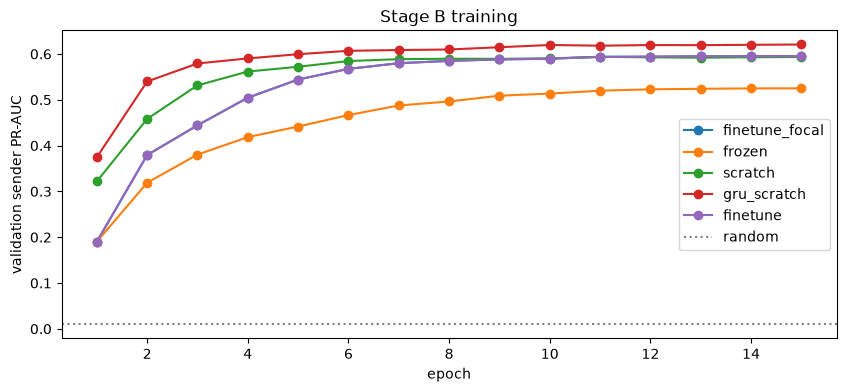

In [96]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, out in B_OUT.items():
    if name.startswith("finetune_") and name != f"finetune_{LOSS_B}":
        continue
    ax.plot(out["history"]["epoch"], out["history"]["val PR-AUC"], marker="o", label=name)
ax.axhline(Y_VAL.mean(), color="gray", ls=":", label="random")
ax.set_xlabel("epoch"); ax.set_ylabel("validation sender PR-AUC"); ax.legend(); ax.set_title("Stage B training")
plt.show()

### Combinando Stage A y Stage B

La estrategia pre-entrenada con mejor PR-AUC de validación es el modelo Stage B del sistema final. El peso de la
mezcla se elige en validación.

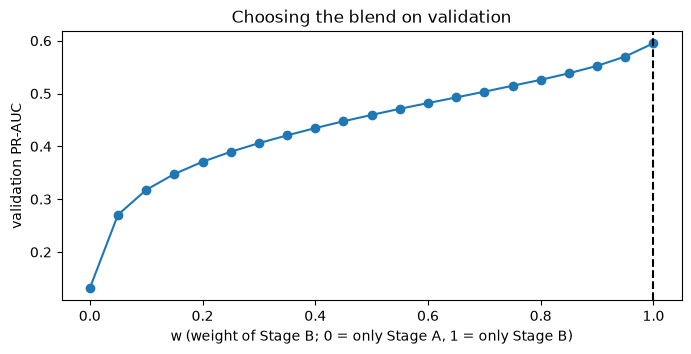

Stage B model in the final system: finetune | blend weight w = 1.0 | final threshold 0.995


In [97]:
def percentile_vs(ref, x):
    ref = np.sort(np.asarray(ref)); return np.searchsorted(ref, np.asarray(x), side="right") / len(ref)

def b_sender_scores(name, split):
    ids = VAL_SENDERS if split == "val" else TEST_SENDERS
    return local_to_senders(B_OUT[name][f"{split}_logit"], SETS[split], "max").reindex(ids).to_numpy()

FINAL_B = max(["finetune", "frozen"], key=lambda n: B_OUT[n]["best_val_pr_auc"])
SB_VAL, SB_TEST = b_sender_scores(FINAL_B, "val"), b_sender_scores(FINAL_B, "test")
PA_VAL, PA_TEST = percentile_vs(SA_VAL, SA_VAL), percentile_vs(SA_VAL, SA_TEST)
PB_VAL, PB_TEST = percentile_vs(SB_VAL, SB_VAL), percentile_vs(SB_VAL, SB_TEST)

w_rows = []
for w in np.round(np.arange(0, 1.0001, 0.05), 2):
    blend = w * PB_VAL + (1 - w) * PA_VAL
    w_rows.append({"w": w, "val PR-AUC": average_precision(Y_VAL, blend), "val recall @5%": recall_at_budget(Y_VAL, blend, 0.05)})
w_tbl = pd.DataFrame(w_rows)
W_BLEND = float(w_tbl.loc[w_tbl["val PR-AUC"].idxmax(), "w"])
FINAL_VAL = W_BLEND * PB_VAL + (1 - W_BLEND) * PA_VAL
FINAL_TEST = W_BLEND * PB_TEST + (1 - W_BLEND) * PA_TEST
THR_FINAL = best_f1_threshold(Y_VAL, FINAL_VAL)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(w_tbl["w"], w_tbl["val PR-AUC"], marker="o")
ax.axvline(W_BLEND, color="k", ls="--")
ax.set_xlabel("w (weight of Stage B; 0 = only Stage A, 1 = only Stage B)"); ax.set_ylabel("validation PR-AUC")
ax.set_title("Choosing the blend on validation"); plt.show()
print(f"Stage B model in the final system: {FINAL_B} | blend weight w = {W_BLEND} | final threshold {THR_FINAL:.3f}")

### Resultados de la ablación (emisores de test)

`val PR-AUC` es en lo que se basaron las decisiones; todo lo demás es en test, que no se usó para ninguna
decisión. Los umbrales vienen de validación. Los intervalos son bootstrap del 95% sobre emisores de test.

In [98]:
LABELS = {"scratch": "Baseline: Transformer from scratch", "gru_scratch": "GRU from scratch",
          "frozen": "Stage B: frozen Stage A encoder",
          "finetune_focal": "Stage B: fine-tuned, focal loss", "finetune_wbce": "Stage B: fine-tuned, weighted BCE"}
MODELS = {"Stage A only (anomaly score)": (SA_VAL, SA_TEST)}
for key, label in LABELS.items():
    if key in B_OUT:
        MODELS[label] = (b_sender_scores(key, "val"), b_sender_scores(key, "test"))
FINAL_LABEL = f"Final system: {FINAL_B} + Stage A (w = {W_BLEND})"
MODELS[FINAL_LABEL] = (FINAL_VAL, FINAL_TEST)

rows = []
for label, (sv, st) in MODELS.items():
    thr = best_f1_threshold(Y_VAL, sv)
    r = {"model": label, "val PR-AUC": average_precision(Y_VAL, sv), **evaluate(Y_TEST, st, thr)}
    lo, hi = bootstrap_ci(Y_TEST, st, average_precision)
    r["PR-AUC 95% CI"] = f"[{lo:.3f}, {hi:.3f}]"
    lo, hi = bootstrap_ci(Y_TEST, st, lambda y, s: recall_at_budget(y, s, 0.05))
    r["recall @5% 95% CI"] = f"[{lo:.2f}, {hi:.2f}]"
    if label in LABELS.values():
        key = [k for k, v in LABELS.items() if v == label][0]
        r["train minutes"] = B_OUT[key]["minutes"]
    rows.append(r)
ABLATION = pd.DataFrame(rows).set_index("model")
cols = ["val PR-AUC", "PR-AUC", "PR-AUC 95% CI", "lift vs random", "recall @1%", "recall @5%", "recall @5% 95% CI",
        "P@100", "precision @thr", "recall @thr", "F1 @thr", "alert rate @thr", "ROC-AUC", "train minutes"]
display(ABLATION[[c for c in cols if c in ABLATION.columns]])
ABLATION.to_csv(os.path.join(OUT_DIR, "ablation_results.csv"))
print(f"Random PR-AUC on test: {Y_TEST.mean():.4f}")

,val PR-AUC,PR-AUC,PR-AUC 95% CI,lift vs random,recall @1%,recall @5%,recall @5% 95% CI,P@100,precision @thr,recall @thr,F1 @thr,alert rate @thr,ROC-AUC,train minutes
model,,,,,,,,,,,,,,
Stage A only (anomaly score),0.1314,0.1132,"[0.090, 0.141]",12.0261,0.1914,0.4259,"[0.39, 0.47]",0.4200,0.1606,0.2099,0.1820,0.0123,0.7619,NaN
Baseline: Transformer from scratch,0.5938,0.5584,"[0.517, 0.598]",59.3281,0.4959,0.7881,"[0.75, 0.82]",1.0000,0.8500,0.4198,0.5620,0.0046,0.9692,0.3574
GRU from scratch,0.6206,0.5977,"[0.558, 0.637]",63.5031,0.5309,0.8128,"[0.78, 0.85]",1.0000,0.8930,0.4465,0.5953,0.0047,0.9728,0.2340
Stage B: frozen Stage A encoder,0.5249,0.4796,"[0.431, 0.522]",50.9584,0.4383,0.7346,"[0.70, 0.78]",0.9700,0.7143,0.3498,0.4696,0.0046,0.9590,0.1866
"Stage B: fine-tuned, focal loss",0.5951,0.5624,"[0.523, 0.607]",59.7572,0.5041,0.7901,"[0.76, 0.83]",1.0000,0.8973,0.4136,0.5662,0.0043,0.9695,0.3312
"Stage B: fine-tuned, weighted BCE",0.5264,0.4939,"[0.450, 0.536]",52.4755,0.4527,0.7572,"[0.71, 0.79]",0.9700,0.6572,0.3827,0.4837,0.0055,0.9658,0.3232
Final system: finetune + Stage A (w = 1.0),0.5951,0.5624,"[0.523, 0.607]",59.7597,0.5041,0.7901,"[0.76, 0.83]",1.0000,0.8973,0.4136,0.5662,0.0043,0.9695,NaN


Random PR-AUC on test: 0.0094


In [99]:
def paired_bootstrap(y, s1, s2, fn, n_boot=500, seed=SEED):
    """Difference fn(s1) - fn(s2) on the same resampled senders."""
    rng = np.random.default_rng(seed); diffs = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        diffs.append(fn(y[i], s1[i]) - fn(y[i], s2[i]))
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5), (diffs > 0).mean()

comparisons = [("Stage B: fine-tuned", f"Stage B: fine-tuned, {'focal loss' if LOSS_B == 'focal' else 'weighted BCE'}",
                "Baseline: Transformer from scratch"),
               ("Stage B: frozen", "Stage B: frozen Stage A encoder", "Baseline: Transformer from scratch"),
               ("Final system", FINAL_LABEL, f"Stage B: fine-tuned, {'focal loss' if LOSS_B == 'focal' else 'weighted BCE'}"
                if FINAL_B == "finetune" else "Stage B: frozen Stage A encoder"),
               ("Transformer", "Baseline: Transformer from scratch", "GRU from scratch")]
for short, a, b in comparisons:
    if a not in MODELS or b not in MODELS:
        continue
    m, lo, hi, p = paired_bootstrap(Y_TEST, MODELS[a][1], MODELS[b][1], average_precision)
    verdict = "clearly better" if lo > 0 else "clearly worse" if hi < 0 else "not distinguishable from noise"
    print(f"{a}  vs  {b}:\n   PR-AUC difference {m:+.4f} [95% CI {lo:+.4f}, {hi:+.4f}], "
          f"better in {p:.0%} of resamples -> {verdict}")

Stage B: fine-tuned, focal loss  vs  Baseline: Transformer from scratch:
   PR-AUC difference +0.0048 [95% CI -0.0103, +0.0203], better in 70% of resamples -> not distinguishable from noise
Stage B: frozen Stage A encoder  vs  Baseline: Transformer from scratch:
   PR-AUC difference -0.0789 [95% CI -0.1011, -0.0581], better in 0% of resamples -> clearly worse
Final system: finetune + Stage A (w = 1.0)  vs  Stage B: fine-tuned, focal loss:
   PR-AUC difference +0.0000 [95% CI -0.0002, +0.0002], better in 61% of resamples -> not distinguishable from noise
Baseline: Transformer from scratch  vs  GRU from scratch:
   PR-AUC difference -0.0398 [95% CI -0.0571, -0.0240], better in 0% of resamples -> clearly worse


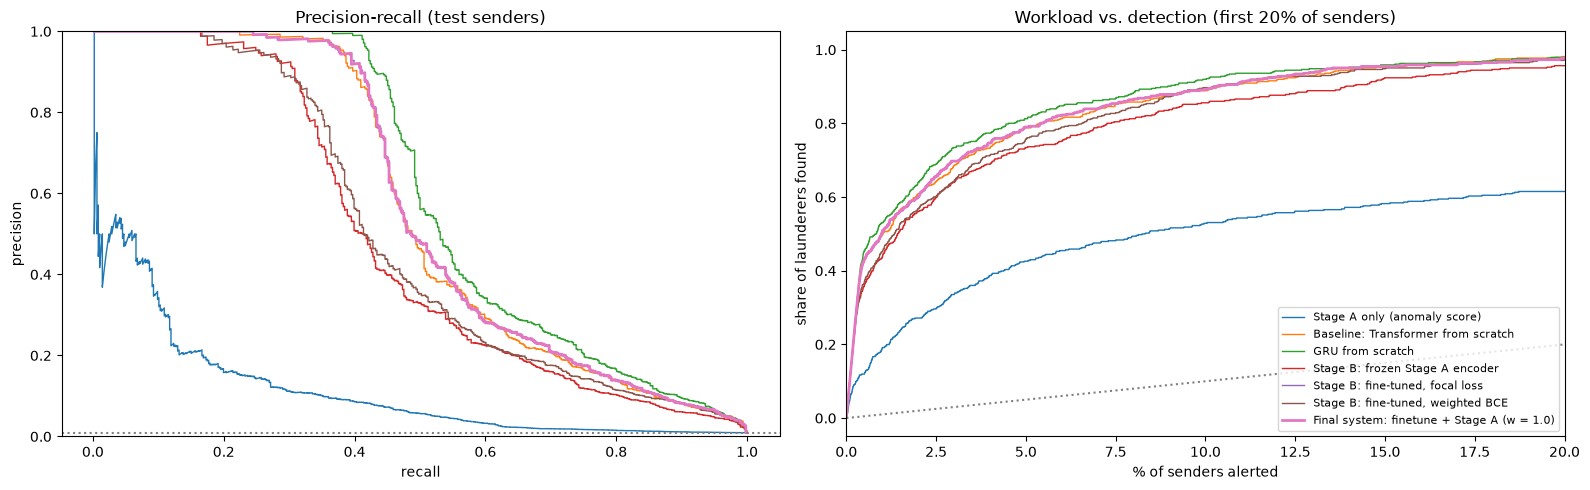

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for label, (sv, st) in MODELS.items():
    o = np.argsort(-st, kind="mergesort"); ys = Y_TEST[o]
    prec = np.cumsum(ys) / np.arange(1, len(ys) + 1); rec = np.cumsum(ys) / ys.sum()
    ax[0].plot(rec, prec, label=label, lw=2 if label == FINAL_LABEL else 1)
    frac = np.arange(1, len(ys) + 1) / len(ys)
    ax[1].plot(frac * 100, rec, label=label, lw=2 if label == FINAL_LABEL else 1)
ax[0].axhline(Y_TEST.mean(), color="gray", ls=":"); ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("Precision-recall (test senders)"); ax[0].set_ylim(0, min(1, ax[0].get_ylim()[1]))
ax[1].plot([0, 100], [0, 1], color="gray", ls=":"); ax[1].set_xlim(0, 20)
ax[1].set_xlabel("% of senders alerted"); ax[1].set_ylabel("share of launderers found")
ax[1].set_title("Workload vs. detection (first 20% of senders)"); ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

In [101]:
# which typologies does each model find when 5% of test senders are alerted?
typ = senders.loc[TEST_SENDERS, ["label", "pattern", "has_tail", "n_tx_total"]].copy()
typ["pattern"] = typ["pattern"].fillna("(no typology)")
for label in ["Stage A only (anomaly score)", "Baseline: Transformer from scratch", FINAL_LABEL]:
    typ[label] = alert_top(MODELS[label][1], 0.05)
pos = typ[typ.label == 1]
by_typ = pos.groupby("pattern")[[c for c in typ.columns if c.startswith(("Stage", "Baseline", "Final"))]].mean()
by_typ.insert(0, "positives", pos.groupby("pattern").size())
display(by_typ.sort_values(FINAL_LABEL, ascending=False))
display(typ.groupby(["label", "has_tail"])[[FINAL_LABEL]].agg(["size", "mean"]))

,positives,Stage A only (anomaly score),Baseline: Transformer from scratch,Final system: finetune + Stage A (w = 1.0)
pattern,,,,
FAN-OUT,3,1.0000,1.0000,1.0000
SCATTER-GATHER,43,0.6047,0.9767,0.9767
CYCLE,35,0.6286,0.9429,0.9429
FAN-IN,51,0.7451,0.9020,0.9020
STACK,58,0.5690,0.8621,0.8966
RANDOM,29,0.5517,0.8621,0.8966
BIPARTITE,30,0.7000,0.8333,0.8333
GATHER-SCATTER,42,0.5952,0.7857,0.8095
(no typology),195,0.1179,0.6462,0.6308


Final system: finetune + Stage A (w = 1.0)       
                                                     size   mean
label has_tail                                                  
0     0                                             51151 0.0430
1     0                                               427 0.7728
      1                                                59 0.9153

**Qué encontramos**

Completar con las tablas de arriba:
- **¿Ayuda el transfer learning?** Comparar el Stage B fine-tuned y congelado con el baseline desde cero, usando
  las líneas de bootstrap pareado. Si la diferencia está dentro del ruido, decirlo; es un resultado legítimo.
- **Congelado vs. fine-tuned:** cuánto vale la representación de Stage A por sí sola versus después de adaptarla.
- **¿Qué aporta la mezcla?** El `w` elegido y la diferencia entre el sistema final y Stage B solo.
- **Transformer vs. GRU:** si la elección de arquitectura hizo una diferencia medible aquí.
- **En términos de negocio:** con 5% de emisores alertados (~2,580 revisiones), qué fracción de lavadores se
  encuentra, y la precision en las top 100 alertas comparada con el 1–5% de los sistemas basados en reglas.
- **Tipologías:** qué patrones detecta el sistema final y cuáles se le siguen escapando, y si los positivos de la
  cola se detectan a una tasa parecida al resto.

## 16. Interpretabilidad: ¿qué transacciones dispararon la alerta?

Para cada ventana, el attention pooling del modelo final de Stage B le da un peso a cada transacción (que suman
1). Eso es lo que un analista vería como heatmap. Los pesos de atención no son automáticamente una explicación
fiel (esto se debate en la literatura), así que no los mostramos sin más: como este dataset nos dice exactamente
qué transacciones son lavado, **medimos si la atención realmente cae sobre ellas**, y lo comparamos con el error
de reconstrucción por transacción de Stage A, que es una segunda señal independiente.

In [102]:
TEST_IDX = SETS["test"]
ATT_TEST = B_OUT[FINAL_B]["test_attn"]
win_tbl = pd.DataFrame({"window": TEST_IDX, "sender": SENDER_OF[TEST_IDX], "logit": B_OUT[FINAL_B]["test_logit"]})
best_window = win_tbl.loc[win_tbl.groupby("sender")["logit"].idxmax()].set_index("sender")["window"]

final_tbl = pd.DataFrame({"label": Y_TEST, "final": FINAL_TEST, "classifier pct": PB_TEST, "anomaly pct": PA_TEST},
                         index=TEST_SENDERS)
final_tbl["alert"] = alert_top(FINAL_TEST, 0.05)
final_tbl["best window"] = best_window.reindex(final_tbl.index).astype(int)
final_tbl["rank pct"] = percentile_vs(FINAL_TEST, FINAL_TEST)

def local(g):
    return int(np.searchsorted(TEST_IDX, g))

hit_rows = []
for sid, r in final_tbl[(final_tbl.label == 1) & final_tbl.alert].iterrows():
    g = int(r["best window"]); n = int(LEN[g]); yt = Y_TX[g, :n]
    if yt.sum() == 0 or n < 2:
        continue
    att, er = ATT_TEST[local(g), :n], TXERR_A[g, :n]
    hit_rows.append({"length": n, "top attention is laundering": yt[att.argmax()] == 1,
                     "top Stage A error is laundering": yt[er.argmax()] == 1,
                     "random pick is laundering": yt.mean(),
                     "attention on laundering tx": att[yt == 1].sum(), "laundering share of window": yt.mean()})
HIT = pd.DataFrame(hit_rows)
if len(HIT):
    display(HIT.drop(columns="length").mean().to_frame("average over detected positives"))
    print(f"n = {len(HIT)} detected positive senders whose top window contains laundering")
    print(f"Attention puts {HIT['attention on laundering tx'].mean():.0%} of its weight on laundering transactions "
          f"that make up {HIT['laundering share of window'].mean():.0%} of those windows.")

,average over detected positives
top attention is laundering,0.7474
top Stage A error is laundering,0.6719
random pick is laundering,0.2357
attention on laundering tx,0.6748
laundering share of window,0.2357


n = 384 detected positive senders whose top window contains laundering
Attention puts 67% of its weight on laundering transactions that make up 24% of those windows.


**Qué encontramos**

Completar: cuán seguido la transacción más atendida es una transacción de lavado real comparado con una elección
aleatoria y con el error más alto de Stage A, y qué tan concentrada está la atención en transacciones de lavado.

### Casos de estudio: tres detecciones y dos errores

Elegidos automáticamente de test: los tres verdaderos positivos mejor rankeados, el falso positivo mejor
rankeado, y el positivo con tipología conocida que el sistema rankeó más bajo. Para cada uno, el heatmap de
atención y el error por transacción de Stage A, la tabla de transacciones, y una explicación generada
automáticamente (el mismo texto que mostraría el MVP).

True positive #1 | label 1 | final score 1.000 | alerted (top 5%): True
Sender 19318_80AF1F630 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 99%). Its riskiest window has 5 transactions over 252 hours; 60% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #5 (19,031 USD by ACH, to a new receiver that had already received money from 12 different senders, -0 minutes after the previous payment); #2 (31,767 USD by Reinvestment, to a receiver it had paid before); #4 (19,031 USD by ACH, to a receiver it had paid before), which together receive 99% of the attention.


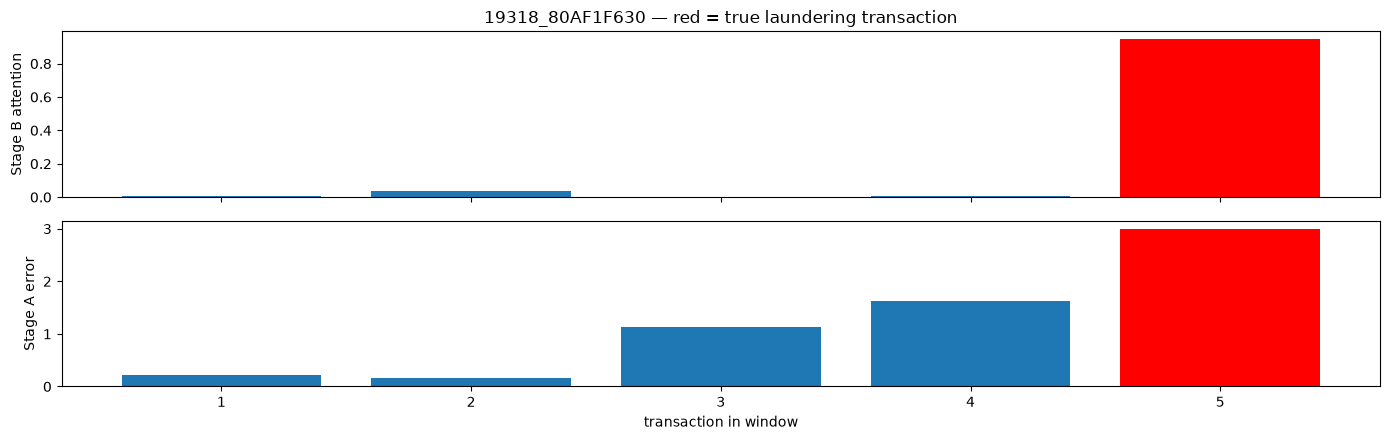

,pos,ts,amt_usd,pay_format,pay_currency,receiver_name,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,2022-09-01 00:04:00,24.6900,Reinvestment,Yuan,19318_80AF1F630,1,1,-0.0000,0.0050,0.2170,0,NaN
1,2,2022-09-01 11:46:00,"31,767.0800",Reinvestment,Yuan,19318_80AF1F630,0,1,702.0000,0.0370,0.1690,0,NaN
2,3,2022-09-03 01:48:00,"2,950.9400",ACH,Yuan,225622_80AF24890,1,44,"2,282.0000",0.0030,1.1310,0,NaN
3,4,2022-09-11 11:56:00,"19,030.7100",ACH,Yuan,19318_80AF1F630,0,1,"12,128.0000",0.0090,1.6270,0,NaN
4,5,2022-09-11 11:56:00,"19,030.7000",ACH,Australian Dollar,27755_80A2DF610,1,12,-0.0000,0.9460,3.0030,1,FAN-IN


True positive #2 | label 1 | final score 1.000 | alerted (top 5%): True
Sender 11974_803C66270 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 97%). Its riskiest window has 6 transactions over 205 hours; 67% are ACH and 4 go to new receivers. The model's attention concentrates on transactions #6 (14,522 USD by ACH, to a new receiver, -0 minutes after the previous payment); #4 (3,045 USD by ACH, to a new receiver); #2 (31,355 USD by Reinvestment, to a receiver it had paid before, 5 minutes after the previous payment), which together receive 96% of the attention.


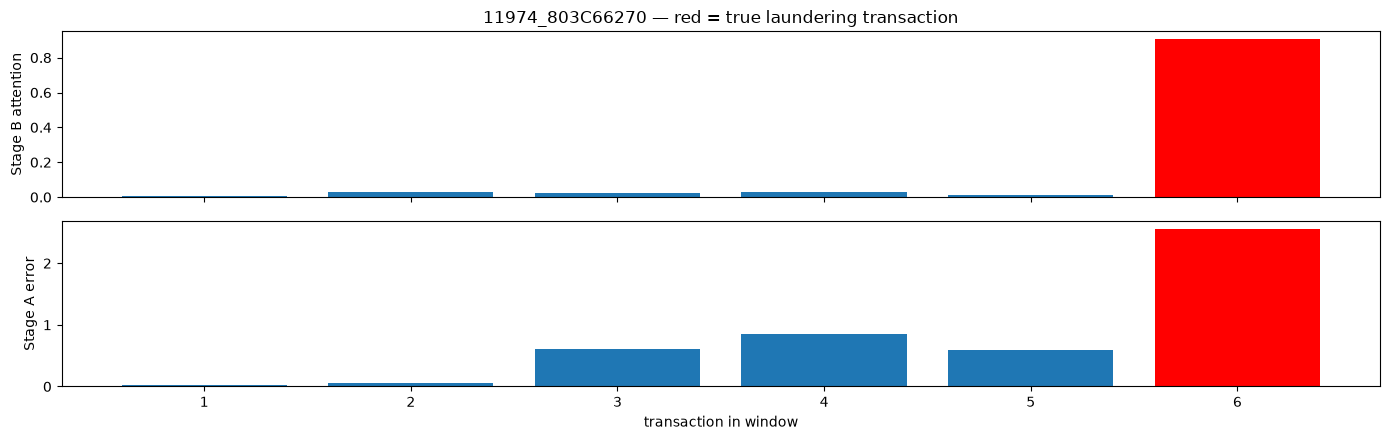

,pos,ts,amt_usd,pay_format,pay_currency,receiver_name,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,2022-09-01 00:04:00,4.7800,Reinvestment,US Dollar,11974_803C66270,1,1,-0.0000,0.0040,0.0190,0,NaN
1,2,2022-09-01 00:09:00,"31,354.8700",Reinvestment,US Dollar,11974_803C66270,0,1,5.0000,0.0270,0.0520,0,NaN
2,3,2022-09-01 00:28:00,"12,124,574.0000",ACH,US Dollar,11107_803C662C0,1,1,19.0000,0.0230,0.6140,0,NaN
3,4,2022-09-04 13:00:00,"3,045.2300",ACH,US Dollar,23833_803C66090,1,2,"5,072.0000",0.0310,0.8590,0,NaN
4,5,2022-09-09 12:54:00,"14,522.2400",ACH,US Dollar,11974_803C66270,0,1,"7,194.0000",0.0100,0.5930,0,NaN
5,6,2022-09-09 12:54:00,"14,522.2400",ACH,Australian Dollar,27755_80A2DF610,1,6,-0.0000,0.9060,2.5610,1,FAN-IN


True positive #3 | label 1 | final score 1.000 | alerted (top 5%): True
Sender 13554_8018BB080 is in the top 0.0% of senders by risk (classifier percentile 100%, anomaly percentile 96%). Its riskiest window has 16 transactions over 225 hours; 94% are ACH and 10 go to new receivers. The model's attention concentrates on transactions #16 (17,840 USD by ACH, to a new receiver that had already received money from 10 different senders, -0 minutes after the previous payment); #6 (19,190 USD by ACH, to a new receiver, -0 minutes after the previous payment); #10 (4,172 USD by ACH, to a new receiver, -0 minutes after the previous payment), which together receive 72% of the attention.


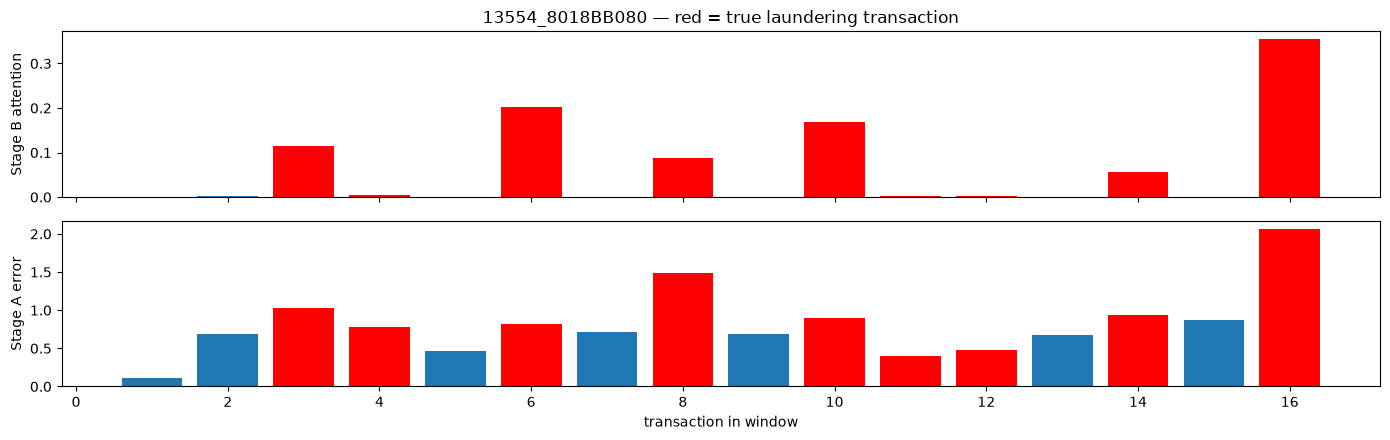

,pos,ts,amt_usd,pay_format,pay_currency,receiver_name,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,2022-09-01 14:24:00,15.1700,Reinvestment,Euro,13554_8018BB080,1,1,-0.0000,0.0010,0.1090,0,NaN
1,2,2022-09-07 03:15:00,"9,863.4800",ACH,Euro,13554_8018BB080,0,1,"7,971.0000",0.0020,0.6860,0,NaN
2,3,2022-09-07 03:15:00,"9,863.4800",ACH,US Dollar,1292_800473820,1,2,-0.0000,0.1140,1.0320,1,SCATTER-GATHER
3,4,2022-09-07 12:22:00,"18,517.4400",ACH,Euro,1299_801EF79E0,1,3,547.0000,0.0060,0.7730,1,SCATTER-GATHER
4,5,2022-09-07 14:59:00,"19,189.5200",ACH,Euro,13554_8018BB080,0,1,157.0000,0.0010,0.4710,0,NaN
5,6,2022-09-07 14:59:00,"19,189.5300",ACH,US Dollar,10_801998160,1,2,-0.0000,0.2020,0.8180,1,SCATTER-GATHER
6,7,2022-09-08 12:57:00,"3,640.9700",ACH,Euro,13554_8018BB080,0,1,"1,318.0000",0.0000,0.7090,0,NaN
7,8,2022-09-08 12:57:00,"3,640.9700",ACH,US Dollar,11157_8010D6C80,1,6,-0.0000,0.0880,1.4890,1,SCATTER-GATHER
8,9,2022-09-08 23:18:00,"4,172.2200",ACH,Euro,13554_8018BB080,0,1,621.0000,0.0000,0.6870,0,NaN
9,10,2022-09-08 23:18:00,"4,172.2100",ACH,US Dollar,11471_8016A8DE0,1,4,-0.0000,0.1690,0.9040,1,SCATTER-GATHER


False positive | label 0 | final score 0.997 | alerted (top 5%): True
Sender 2439_80293DD80 is in the top 0.2% of senders by risk (classifier percentile 100%, anomaly percentile 98%). Its riskiest window has 32 transactions over 74 hours; 31% are ACH and 5 go to new receivers. The model's attention concentrates on transactions #12 (76,034 USD by ACH, to a new receiver, -0 minutes after the previous payment); #20 (76,034 USD by ACH, to a receiver it had paid before, -0 minutes after the previous payment); #11 (76,034 USD by ACH, to a new receiver, 10 minutes after the previous payment), which together receive 88% of the attention.


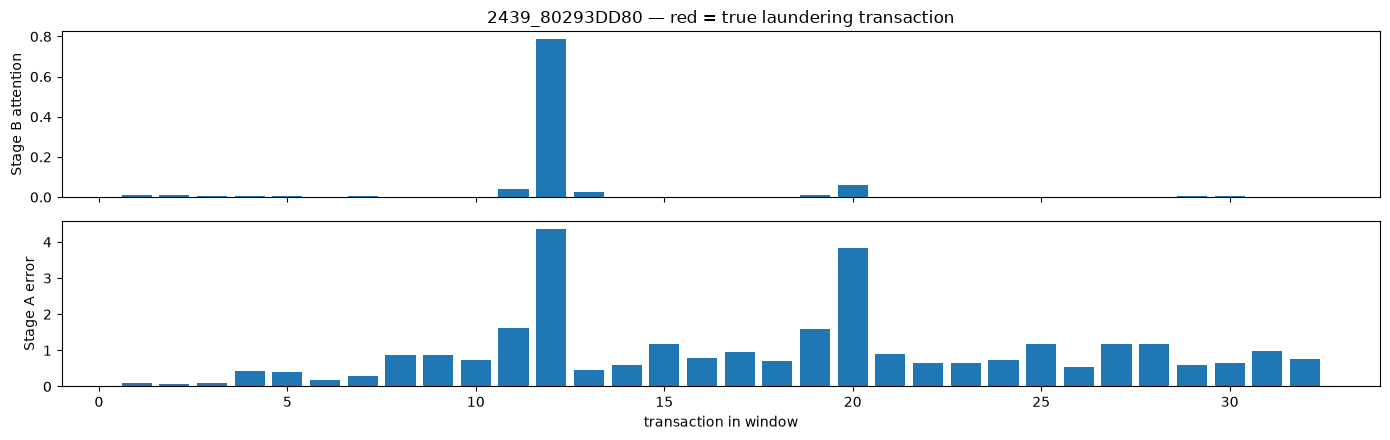

,pos,ts,amt_usd,pay_format,pay_currency,receiver_name,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,2022-09-01 01:09:00,"2,857.2100",Cheque,US Dollar,138630_80E449920,1,3,54.0000,0.0110,0.0920,0,NaN
1,2,2022-09-01 01:10:00,"7,381.3200",Credit Card,US Dollar,138630_80E449920,0,3,1.0000,0.0110,0.0560,0,NaN
2,3,2022-09-01 01:23:00,673.7900,ACH,US Dollar,138630_80E449920,0,3,13.0000,0.0070,0.0850,0,NaN
3,4,2022-09-01 01:26:00,238.5400,Cash,US Dollar,138630_80E449920,0,3,3.0000,0.0030,0.4270,0,NaN
4,5,2022-09-01 14:51:00,185.8200,Cheque,US Dollar,2991_802E01F70,1,2,805.0000,0.0060,0.3880,0,NaN
5,6,2022-09-01 14:51:00,143.3900,Credit Card,US Dollar,2991_802E01F70,0,2,-0.0000,0.0010,0.1740,0,NaN
6,7,2022-09-01 22:36:00,"1,470.6900",Cheque,US Dollar,11974_803E1D000,1,3,465.0000,0.0040,0.2960,0,NaN
7,8,2022-09-01 22:37:00,53.2300,ACH,US Dollar,11974_803E1D000,0,3,1.0000,0.0020,0.8780,0,NaN
8,9,2022-09-01 22:43:00,623.1500,Credit Card,US Dollar,11974_803E1D000,0,3,6.0000,0.0000,0.8800,0,NaN
9,10,2022-09-01 22:44:00,174.1600,Cash,US Dollar,11974_803E1D000,0,3,1.0000,0.0010,0.7260,0,NaN


False negative | label 1 | final score 0.768 | alerted (top 5%): False
Sender 1267_8047B6D80 is in the top 23.0% of senders by risk (classifier percentile 77%, anomaly percentile 97%). Its riskiest window has 31 transactions over 192 hours; 29% are ACH and 3 go to new receivers. The model's attention concentrates on transactions #2 (8,809 USD by ACH, to a new receiver, -0 minutes after the previous payment); #1 (8,809 USD by ACH, to a new receiver); #15 (5,835 USD by ACH, to a receiver it had paid before, 1 minutes after the previous payment), which together receive 78% of the attention.


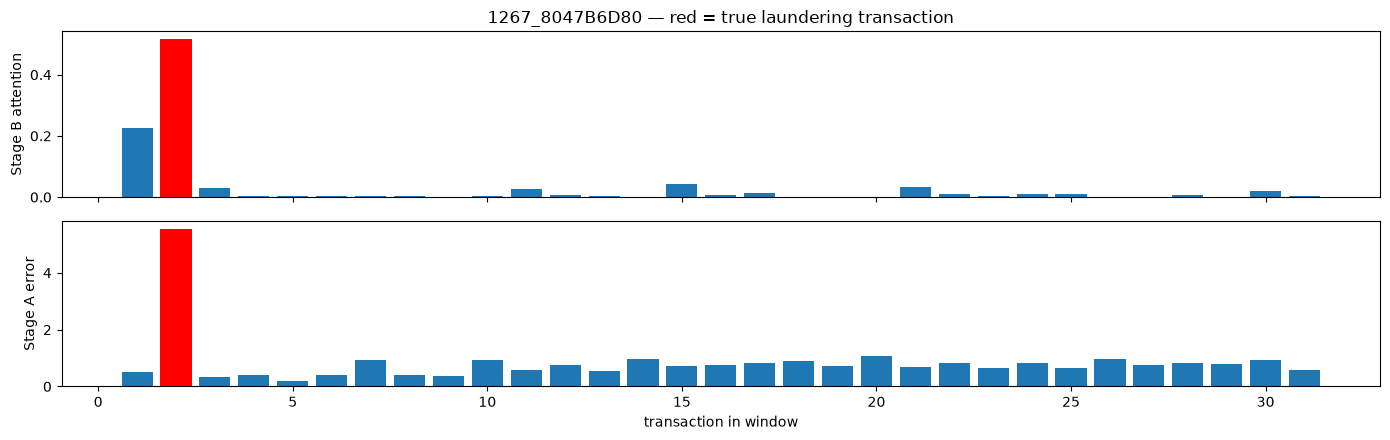

,pos,ts,amt_usd,pay_format,pay_currency,receiver_name,new receiver,receiver senders so far,gap min,attention,stage A error,is_laundering,pattern
0,1,2022-09-01 07:57:00,"8,808.7300",ACH,Yuan,1267_8047B6D80,1,1,-0.0000,0.2270,0.5130,0,NaN
1,2,2022-09-01 07:57:00,"8,808.7300",ACH,Canadian Dollar,214_8090E3020,1,2,-0.0000,0.5160,5.5590,1,BIPARTITE
2,3,2022-09-01 16:35:00,"87,085.9300",Cheque,Yuan,51283_8142718A0,1,2,518.0000,0.0290,0.3520,0,NaN
3,4,2022-09-01 16:39:00,"10,956.7500",Credit Card,Yuan,51283_8142718A0,0,2,4.0000,0.0030,0.3970,0,NaN
4,5,2022-09-01 16:39:00,"38,455.0700",Cash,Yuan,51283_8142718A0,0,2,-0.0000,0.0030,0.1870,0,NaN
5,6,2022-09-01 16:44:00,"5,834.8700",ACH,Yuan,51283_8142718A0,0,2,5.0000,0.0030,0.4150,0,NaN
6,7,2022-09-01 19:51:00,"16,152.4900",Reinvestment,Yuan,1267_8047B6D80,0,2,187.0000,0.0050,0.9220,0,NaN
7,8,2022-09-02 21:46:00,"87,085.9300",Cheque,Yuan,51283_8142718A0,0,3,"1,555.0000",0.0040,0.4170,0,NaN
8,9,2022-09-02 21:55:00,"10,956.7500",Credit Card,Yuan,51283_8142718A0,0,3,9.0000,0.0010,0.3790,0,NaN
9,10,2022-09-02 21:55:00,"38,455.0700",Cash,Yuan,51283_8142718A0,0,3,-0.0000,0.0030,0.9170,0,NaN


In [103]:
def load_table(name):
    p = os.path.join(OUT_DIR, name + ".parquet")
    return pd.read_parquet(p) if os.path.exists(p) else pd.read_csv(os.path.join(OUT_DIR, name + ".csv"), parse_dates=["ts"])
TX_VIEW = load_table("eval_transactions")

def raw_feature(g, f):
    v = X_num[g, :LEN[g], NUM_FEATURES.index(f)].astype(np.float64)
    if f in NORM:
        v = v * NORM[f]["std"] + NORM[f]["mean"]
    return v

def case_table(sid):
    r = final_tbl.loc[sid]; g = int(r["best window"]); n = int(LEN[g])
    tx = TX_VIEW[TX_VIEW["seq"] == g].sort_values("pos").reset_index(drop=True)
    tx["attention"] = ATT_TEST[local(g), :n]
    tx["stage A error"] = TXERR_A[g, :n]
    tx["gap min"] = np.expm1(raw_feature(g, "log_gap"))
    tx["new receiver"] = raw_feature(g, "is_new_receiver").round().astype(int)
    tx["receiver senders so far"] = np.expm1(raw_feature(g, "log_recv_senders")).round().astype(int)
    return r, g, tx

def explain(sid):
    r, g, tx = case_table(sid)
    top = tx.sort_values("attention", ascending=False).head(3)
    parts = []
    for _, t in top.iterrows():
        d = f"#{int(t['pos']) + 1} ({t['amt_usd']:,.0f} USD by {t['pay_format']}"
        d += ", to a new receiver" if t["new receiver"] else ", to a receiver it had paid before"
        if t["receiver senders so far"] >= 10:
            d += f" that had already received money from {int(t['receiver senders so far'])} different senders"
        if t["pos"] > 0 and t["gap min"] < 60:
            d += f", {t['gap min']:.0f} minutes after the previous payment"
        parts.append(d + ")")
    span_h = (tx["ts"].max() - tx["ts"].min()).total_seconds() / 3600
    top_share = 1 - r["rank pct"]
    return (f"Sender {senders.loc[sid, 'sender_name']} is in the top {max(top_share, 1 / len(final_tbl)):.1%} of senders by risk "
            f"(classifier percentile {r['classifier pct']:.0%}, anomaly percentile {r['anomaly pct']:.0%}). "
            f"Its riskiest window has {len(tx)} transactions over {span_h:.0f} hours; "
            f"{(tx['pay_format'] == 'ACH').mean():.0%} are ACH and {int(tx['new receiver'].sum())} go to new receivers. "
            f"The model's attention concentrates on transactions " + "; ".join(parts) +
            f", which together receive {top['attention'].sum():.0%} of the attention.")

def show_case(sid, title):
    r, g, tx = case_table(sid)
    print("=" * 110); print(f"{title} | label {int(r['label'])} | final score {r['final']:.3f} | "
                            f"alerted (top 5%): {bool(r['alert'])}")
    print(explain(sid))
    colors = np.where(tx["is_laundering"] == 1, "red", "tab:blue")
    fig, ax = plt.subplots(2, 1, figsize=(14, 4.5), sharex=True)
    ax[0].bar(tx["pos"] + 1, tx["attention"], color=colors); ax[0].set_ylabel("Stage B attention")
    ax[0].set_title(f"{senders.loc[sid, 'sender_name']} — red = true laundering transaction")
    ax[1].bar(tx["pos"] + 1, tx["stage A error"], color=colors); ax[1].set_ylabel("Stage A error")
    ax[1].set_xlabel("transaction in window")
    plt.tight_layout(); plt.show()
    display(tx[["pos", "ts", "amt_usd", "pay_format", "pay_currency", "receiver_name", "new receiver",
                "receiver senders so far", "gap min", "attention", "stage A error", "is_laundering", "pattern"]]
              .assign(pos=lambda d: d["pos"] + 1).round({"amt_usd": 2, "gap min": 1, "attention": 3, "stage A error": 3}))

ranked = final_tbl.sort_values("final", ascending=False)
long_enough = ranked["best window"].map(lambda g: LEN[g] >= 5)
has_laund = ranked["best window"].map(lambda g: Y_TX[g].sum() > 0)
CASES = []
CASES += [(sid, f"True positive #{i + 1}") for i, sid in enumerate(ranked[(ranked.label == 1) & long_enough & has_laund].index[:3])]
CASES += [(sid, "False positive") for sid in ranked[(ranked.label == 0) & long_enough].index[:1]]
fn_pool = ranked[(ranked.label == 1) & long_enough & has_laund]
fn_pool = fn_pool[senders.loc[fn_pool.index, "pattern"].notna().to_numpy()]
CASES += [(sid, "False negative") for sid in fn_pool.index[-1:]]
for sid, title in CASES:
    show_case(sid, title)

**Qué encontramos**

Completar para cada uno de los cinco casos: en qué se enfocó el modelo, si calza con las transacciones de lavado
reales, a qué tipología conocida se parece (fan-out, structuring en varios pagos, ráfagas a receptores nuevos...),
y para los dos errores, por qué se equivocó el modelo (ej. un emisor legítimo con pagos en ráfaga a muchos
receptores nuevos, o un emisor de fan-in cuyo único pago se ve ordinario).

In [104]:
torch.save({"state_dict": B_RUNS[FINAL_B]["model"].state_dict(), "strategy": FINAL_B, "loss": LOSS_B,
            "cfg_a": CFG_A, "cfg_b": CFG_B}, os.path.join(OUT_DIR, "stage_b.pt"))
final_tbl.assign(sender_name=senders.loc[final_tbl.index, "sender_name"]).reset_index(names="sender") \
         .pipe(save_table, "final_test_senders")
np.save(os.path.join(OUT_DIR, "stage_b_test_attention.npy"), ATT_TEST.astype(np.float32))
with open(os.path.join(OUT_DIR, "final_system.json"), "w") as f:
    json.dump({"stage_b_strategy": FINAL_B, "loss": LOSS_B, "blend_w": W_BLEND, "threshold": THR_FINAL,
               "stage_a_window_score": A_WINDOW_NAME, "stage_a_agg": A_AGG,
               "val_reference_stage_a": np.sort(SA_VAL).tolist()[::50],
               "val_reference_stage_b": np.sort(SB_VAL).tolist()[::50]}, f)
print(sorted(os.listdir(OUT_DIR)))
print(f"Total runtime {elapsed()}")

['MASK.npy', 'TX_ID.npy', 'X_cur.npy', 'X_fmt.npy', 'X_num.npy', 'Y_TX.npy', 'ablation_results.csv', 'eval_transactions.parquet', 'final_system.json', 'final_test_senders.parquet', 'idx_stage_a_train.npy', 'idx_stage_b_train.npy', 'idx_test.npy', 'idx_val.npy', 'meta.json', 'poolw_a.npy', 'senders.parquet', 'stage_a.pt', 'stage_a_history.csv', 'stage_a_scoring_candidates.csv', 'stage_b.pt', 'stage_b_test_attention.npy', 'txerr_a.npy', 'window_score_a.npy', 'windows.parquet']
Total runtime [101.9 min]


## Resumen y limitaciones (borrador para el reporte)

- **Datos:** datos sintéticos con artefactos conocidos (la cola, scheduling del simulador por hora y día);
  evitamos tiempo absoluto y hora del día para que el modelo no pueda aprenderlos.
- **Vista por emisor:** el lavado es un fenómeno de red. Las secuencias por emisor solo ven un lado; el feature
  de receptor punto-en-el-tiempo agrega algo de contexto, pero modelos del lado del receptor y de grafo (ej.
  graph neural networks sobre la red de transacciones) ven patrones como fan-in mucho mejor.
- **Emisores de una sola transacción** (31% de emisores) quedan fuera del alcance de un modelo de secuencias.
- **Evaluación:** una sola semilla aleatoria por modelo; los intervalos bootstrap muestran cuánto de cada
  diferencia podría ser ruido.
- **Para llegar a producción:** casos reales etiquetados (reportes de actividad sospechosa), calibración de
  probabilidades, reentrenamiento periódico a medida que cambia el comportamiento, monitoreo de volumen de
  alertas, y un paso de revisión humana para cada alerta.

## Notas / experimentos propios